In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import spikeinterface.preprocessing as spp
import spikeinterface.full as si
import xarray as xr
from scipy import stats
import statsmodels.api as sm
from spectral_connectivity import Connectivity, Multitaper
import json
from hypo_sleep import Session, NumpyDecoder
import time

In [2]:
SMALL_SIZE = 20
MEDIUM_SIZE = 24
BIGGER_SIZE = 28
BIGGEST_SIZE = 38

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=BIGGER_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)
plt.rc("figure", labelsize=BIGGEST_SIZE)

In [3]:
def xr_baseline_correction(data, baseline_segment):
    if not isinstance(baseline_segment, slice):
        baseline_segment = slice(baseline_segment[0], baseline_segment[1])
    baseline_data = data.sel(time=baseline_segment).copy()
    corrected_data = (
        (data - baseline_data.mean(dim="time")) / baseline_data.mean(dim="time")
    ) * 100
    return corrected_data

In [4]:
data_path = Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/")
full_dict = {
    "none": {
        "dates": [
            "2024-05-21_10-28-00",
            "2024-05-23_06-00-36",
            "2024-07-22_10-47-00",
            "2024-07-23_05-47-21",
            "2024-07-23_12-06-25",
            "2024-07-25_05-55-34",
            "2024-07-25_12-18-59",
            "2025-02-18_09-19-26",
            "2025-02-20_08-58-57",
            "2025-03-20_09-01-41",
            "2025-02-24_09-00-29",
            # "2025-02-26_09-05-08",
        ],
        "configs": [
            "55a4",
            "929a",
            "3ad9",
            "20a7",
            "f9f7",
            "1f25",
            "70eb",
            "5d77",
            "790d",
            "8a55",
            "3e4b",
            # "d205",
        ],
        "animal": [
            "HYDO01",
            "HYDO01",
            "HYDO02",
            "HYDO02",
            "HYDO02",
            "HYDO02",
            "HYDO02",
            "HYDO03",
            "HYDO03",
            "HYDO03",
            "HYDO04",
        ],  # "HYDO04"],
    },
    "sleep": {
        "dates": [
            "2025-02-19_08-59-23",
            "2025-03-03_08-55-10",
            "2025-02-25_09-06-23",
            "2025-03-07_08-52-44",
        ],
        "configs": [
            "d628",
            "c687",
            "073a",
            "9080",
        ],
        "animal": ["HYDO03", "HYDO03", "HYDO04", "HYDO04"],
    },
    "food": {
        "dates": [
            "2025-02-21_09-04-29",
            "2025-02-28_09-02-06",
            "2025-03-04_08-55-25",
        ],
        "configs": [
            "a964",
            "0674",
            "bc96",
        ],
        "animal": ["HYDO03", "HYDO03", "HYDO04"],
    },
}
depth_ordered_chs = {
    "HYDO01": np.array(
        [
            "14",
            "31",
            "1",
            "16",
            "13",
            "15",
            "2",
            "30",
            "0",
            "17",
            "12",
            "9",
            "3",
            "29",
            "6",
            "18",
            "11",
            "8",
            "4",
            "28",
            "7",
            "19",
            "25",
            "5",
            "26",
            "22",
            "21",
            "24",
            "20",
            "23",
        ]
    ),
    "HYDO02": np.array(
        [
            "14",
            "31",
            "1",
            "16",
            "13",
            "15",
            "2",
            "30",
            "0",
            "17",
            "12",
            "9",
            "3",
            "29",
            "6",
            "18",
            "11",
            "8",
            "4",
            "28",
            "7",
            "19",
            "25",
            "5",
            "26",
            "22",
            "21",
            "24",
            "20",
            "23",
        ]
    ),
    "HYDO03": np.array(
        [
            "24",
            "23",
            "25",
            "22",
            "8",
            "7",
            "9",
            "6",
            "15",
            "0",
            "14",
            "1",
            "26",
            "21",
            "27",
            "20",
            "10",
            "5",
            "28",
            "19",
            "11",
            "4",
            "29",
            "18",
            "12",
            "3",
            "30",
            "17",
            "13",
            "2",
            "31",
            "16",
        ]
    ),
    "HYDO04": np.array(
        [
            "24",
            "23",
            "25",
            "22",
            "8",
            "7",
            "9",
            "6",
            "15",
            "0",
            "14",
            "1",
            "26",
            "21",
            "27",
            "20",
            "10",
            "5",
            "28",
            "19",
            "11",
            "4",
            "29",
            "18",
            "12",
            "3",
            "30",
            "17",
            "13",
            "2",
            "31",
            "16",
        ]
    ),
}
triggers = ["spi-peak", "so-peak", "nrem-null"]

In [5]:
animal_dict = full_dict["none"]
animals = ["HYDO01", "HYDO02", "HYDO03", "HYDO04"]
spi_traces = {
    tmp_animal: {
        date: {
            region: {filt_type: {} for filt_type in ["raw", "spi"]}
            for region in ["ctx", "hyp"]
        }
        for an2, date in zip(animal_dict["animal"], animal_dict["dates"])
        if an2 == tmp_animal
    }
    for tmp_animal in animals
}  # nevents, ntimepoints, nchannels

In [59]:
config_path = Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/")
session_dict = {}
animal_dict = full_dict["none"]
for animal, date, config_id in zip(
    animal_dict["animal"], animal_dict["dates"], animal_dict["configs"]
):
    with open(Path(config_path, animal, date, config_id, "state_dict.json"), "r") as f:
        state_dict = json.load(f, cls=NumpyDecoder)
    session_dict[date] = state_dict

In [84]:
window = (
    3.501  # need 0.001 buffer to make sure we get the faull window with time slicing
)
animal_dict = full_dict["none"]
animals = ["HYDO01", "HYDO02", "HYDO03", "HYDO04"]
spi_traces = {
    tmp_animal: {
        date: {
            region: {filt_type: {} for filt_type in ["raw", "spi"]}
            for region in ["ctx", "hyp"]
        }
        for an2, date in zip(animal_dict["animal"], animal_dict["dates"])
        if an2 == tmp_animal
    }
    for tmp_animal in animals
}  # nevents, ntimepoints, nchannels
spi_times = {date: None for date in animal_dict["dates"]}
so_traces = {
    tmp_animal: {
        date: {
            region: {filt_type: {} for filt_type in ["raw", "so"]}
            for region in ["ctx", "hyp"]
        }
        for an2, date in zip(animal_dict["animal"], animal_dict["dates"])
        if an2 == tmp_animal
    }
    for tmp_animal in animals
}  # nevents, ntimepoints, nchannels
so_times = {date: None for date in animal_dict["dates"]}
rec_dict = {
    tmp_animal: {
        date: {"ctx": {}, "hyp": {}}
        for an2, date in zip(animal_dict["animal"], animal_dict["dates"])
        if an2 == tmp_animal
    }
    for tmp_animal in animals
}  # TODO: make this make sense
print("loading traces")

for animal, date, config_id in zip(
    animal_dict["animal"], animal_dict["dates"], animal_dict["configs"]
):
    for region in rec_dict[animal][date].keys():
        for filt_type in ["raw", "so", "spi"]:
            if filt_type == "raw":
                ref_id = (
                    "250_132b_ctx_global_fe80"
                    if region == "hyp"
                    else "250_132b_none_1da2"
                )
            elif filt_type == "so":
                ref_id = (
                    "ctx_global_fe80_so_3c1a"
                    if region == "hyp"
                    else "none_1da2_so_3c1a"
                )
            elif filt_type == "spi":
                ref_id = (
                    "ctx_global_fe80_spindle_a0a3"
                    if region == "hyp"
                    else "none_1da2_spindle_a0a3"
                )
            # ref_id = "ctx_global_fe80_so_3c1a"  # if region == "hyp" else "none_1da2")
            rec_dir = list(Path(data_path, animal, date, "rec", region).glob(ref_id))[0]
            rec_dict[animal][date][region][filt_type] = si.load(rec_dir)
    so_df = pd.read_csv(
        Path(
            data_path,
            f"{animal}/{date}/{config_id}/slow_osc/so-df_ch-39_{config_id}.csv",
        )
    )
    spi_df = pd.read_csv(
        Path(
            data_path,
            f"{animal}/{date}/{config_id}/spindles/spindle_events_ch-39_{config_id}.csv",
        )
    )
    for region, reg_traces in so_traces[animal][date].items():
        for filt_type, traces in reg_traces.items():
            reg_rec = rec_dict[animal][date][region][filt_type]
            if reg_rec.has_channel_location():
                reg_rec = si.depth_order(reg_rec)
            for ch in reg_rec.get_channel_ids():
                ch_rec = reg_rec.select_channels(channel_ids=[ch])
                if ch not in traces.keys():
                    traces[ch] = []
                for _, row in so_df.iterrows():
                    tmp_rec = ch_rec.time_slice(
                        start_time=row.neg_peak_time - window,
                        end_time=row.neg_peak_time + window,
                        # start_time=row.down_crossing - window,
                        # end_time=row.down_crossing + window,
                    )
                    so_traces[animal][date][region][filt_type][ch].append(
                        tmp_rec.get_traces(return_in_uV=True).flatten()[
                            : int(window * 2 * 250)
                        ]
                    )
    so_times[date] = np.asarray(
        so_df.neg_peak_time.apply(lambda x: (x - window, x + window)).tolist()
    )
    for region, reg_traces in spi_traces[animal][date].items():
        for filt_type, traces in reg_traces.items():
            reg_rec = rec_dict[animal][date][region][filt_type]
            if reg_rec.has_channel_location():
                reg_rec = si.depth_order(reg_rec)
            for ch in reg_rec.get_channel_ids():
                ch_rec = reg_rec.select_channels(channel_ids=[ch])
                if ch not in traces.keys():
                    traces[ch] = []
                for _, row in spi_df.iterrows():
                    tmp_rec = ch_rec.time_slice(
                        start_time=row.neg_peak - window,
                        end_time=row.neg_peak + window,
                        # start_time=row.down_crossing - window,
                        # end_time=row.down_crossing + window,
                    )
                    spi_traces[animal][date][region][filt_type][ch].append(
                        tmp_rec.get_traces(return_in_uV=True).flatten()[
                            : int(window * 2 * 250)
                        ]
                    )
    spi_times[date] = np.asarray(
        spi_df.neg_peak.apply(lambda x: (x - window, x + window)).tolist()
    )

loading traces


/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(
/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(
/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(
/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(


In [85]:
for animal, dates in spi_traces.items():
    for date, regions in dates.items():
        for region, reg_traces in regions.items():
            for filt_type, traces in reg_traces.items():
                spi_traces[animal][date][region][filt_type] = {
                    ch: np.stack(ch_traces) for ch, ch_traces in traces.items()
                }
for animal, dates in so_traces.items():
    for date, regions in dates.items():
        for region, reg_traces in regions.items():
            for filt_type, traces in reg_traces.items():
                so_traces[animal][date][region][filt_type] = {
                    ch: np.stack(ch_traces) for ch, ch_traces in traces.items()
                }

In [86]:
date_dict = {
    date: {"ctx": {"spi": {}, "so": {}}, "hyp": {"spi": {}, "so": {}}}
    for date in animal_dict["dates"]
}
for animal, dates in spi_traces.items():
    for date, regions in dates.items():
        for region, reg_traces in regions.items():
            date_dict[date][region]["spi"] = reg_traces["raw"]
for animal, dates in so_traces.items():
    for date, regions in dates.items():
        for region, reg_traces in regions.items():
            date_dict[date][region]["so"] = reg_traces["raw"]

In [102]:
tmp_time = (
    np.arange(np.round(window, 2) * 2 * 250) - (np.round(window, 2) * 250)
) / 250
stack_xr_dict = {trig: {} for trig in ["spi", "so"]}
date_ch_list = {
    date: {trig: [] for trig in ["spi", "so"]} for date in animal_dict["dates"]
}
for date, regions in date_dict.items():
    stacked_traces = {trig: [] for trig in ["spi", "so"]}
    ch_list = {trig: [] for trig in ["spi", "so"]}
    for region, reg_data in regions.items():
        for trig, traces in reg_data.items():
            for ch, ch_traces in traces.items():
                if (region == "ctx") & (ch != "39"):
                    continue
                stacked_traces[trig].append(ch_traces)
                ch_list[trig].append(ch)
    for trig, traces in stacked_traces.items():
        date_ch_list[date][trig] = ch_list[trig]
        stacked_data = np.stack(traces, axis=-1).T
        if trig == "so":
            time_arr = so_times[date]
        else:
            time_arr = spi_times[date]
        stack_xr_dict[trig][date] = xr.DataArray(
            data=stacked_data,
            dims=["channel", "time", "trial"],
            coords={
                "channel": ch_list[trig],
                "trial": np.arange(stacked_data.shape[-1]),
                "time": tmp_time,
                "start_time": ("trial", time_arr[:, 0]),
                "end_time": ("trial", time_arr[:, 1]),
            },
        )

In [46]:
tmp_xr = xr.concat([val for val in stack_xr_dict["so"].values()], dim="trial")
tmp_xr.assign_coords(trial=range(tmp_xr.sizes["trial"]))
pre_event = tmp_xr.sel(time=slice(-3.5, -2.5))
event = tmp_xr.sel(time=slice(-0.5, 0.5))

/tmp/ipykernel_324072/935996703.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'channel' ('channel',) The recommendation is to set join explicitly for this case.
  tmp_xr = xr.concat([val for val in stack_xr_dict["so"].values()], dim="trial")


In [59]:
res = stats.ttest_rel(
    np.abs(event.isel(channel=slice(1, None)).mean(dim=("channel", "trial"))),
    np.abs(pre_event.isel(channel=slice(1, None)).mean(dim=("channel", "trial"))),
    alternative="two-sided",
)
reject, corr, _, _ = sm.stats.multipletests(res.pvalue, method="fdr_bh")

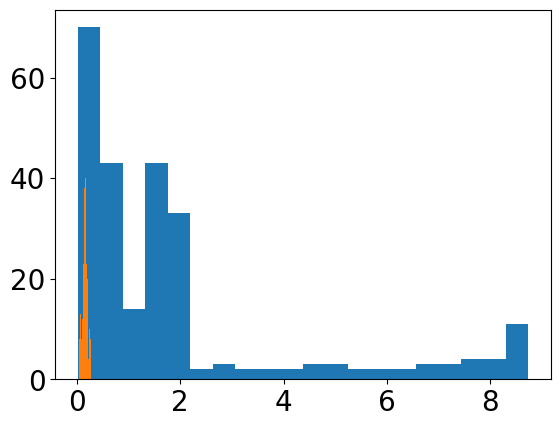

In [47]:
_ = plt.hist(
    np.abs(event.isel(channel=slice(1, None)).mean(dim=("channel", "trial"))), bins="fd"
)
_ = plt.hist(
    np.abs(pre_event.isel(channel=slice(1, None)).mean(dim=("channel", "trial"))),
    bins="fd",
)

In [11]:
def return_bootstrap_sample_idxs(x, size=None):
    return return_bootstrap_sample(np.arange(0, size=size))


def return_bootstrap_sample(x, size=None, rng=None):
    if size is None:
        size = len(x)
    if rng is None:
        rng = np.random.default_rng()
    if len(np.shape(x)) > 1:  # avoid error when nd array; treat each row as a sample
        return np.asarray(x)[return_bootstrap_sample_idxs(x, size)]
    return rng.choice(x, size=size, replace=True)

In [104]:
coh_dict = {
    key: {
        animal: {
            cond: {"coherence": [], "phase": [], "frequency": []}
            for cond in ["peak", "null"]
        }
        for animal in ["HYDO01", "HYDO02", "HYDO03", "HYDO04"]
    }
    for key in ["so", "spi"]
}
trig_xr = {key: None for key in stack_xr_dict.keys()}
for key, trig_dict in stack_xr_dict.items():
    tmp_xr = xr.concat([val for val in trig_dict.values()], dim="trial")
    for date, date_xr in trig_dict.items():
        animal = animal_dict["animal"][animal_dict["dates"].index(date)]
        start_time = time.time()
        state_times = session_dict[date]["NREM"]["times"].T
        xr_epochs = []
        for epoch, (start, stop) in enumerate(state_times):
            epoch_dur = stop - start
            if epoch_dur < 30:
                # print(f"epoch {epoch} is too short: {epoch_dur}s duration")
                continue
            tmp_data = date_xr.where(
                (date_xr.start_time >= start) & (date_xr.end_time <= stop), drop=True
            )
            if tmp_data.trial.size < 3:
                # print(
                #     f"not enough data found for epoch {epoch}: {tmp_data.trial.size} events found"
                # )
                continue
            # peak
            peak_mtm = Multitaper(
                tmp_data.sel(time=slice(-0.5, 0.5)).transpose(
                    "time", "trial", "channel"
                ),
                sampling_frequency=250,
                start_time=tmp_data.time.values[0],
            )
            peak_connectivity = Connectivity.from_multitaper(peak_mtm)
            peak_coherence = peak_connectivity.coherence_magnitude()
            peak_xr_coh = xr.DataArray(
                peak_coherence[0],
                dims=["frequency", "channel1", "channel2"],
                coords={
                    "frequency": peak_connectivity.frequencies,
                    "channel1": date_ch_list[date][trig],
                    "channel2": date_ch_list[date][trig],
                },
            )
            coh_dict[key][animal]["peak"]["coherence"].append(peak_xr_coh)
            # coh_dict[key][animal]["peak"]["phase"].append(
            #     peak_connectivity.coherence_phase()
            # )
            # coh_dict[key][animal]["peak"]["frequency"].append(
            #     peak_connectivity.frequencies
            # )

            # null
            null_mtm = Multitaper(
                tmp_data.sel(time=slice(-2.5, -1.5)).transpose(
                    "time", "trial", "channel"
                ),
                sampling_frequency=250,
                start_time=tmp_data.time.values[0],
            )
            null_connectivity = Connectivity.from_multitaper(null_mtm)
            null_coherence = null_connectivity.coherence_magnitude()
            null_xr_coh = xr.DataArray(
                null_coherence[0],
                dims=["frequency", "channel1", "channel2"],
                coords={
                    "frequency": null_connectivity.frequencies,
                    "channel1": date_ch_list[date][trig],
                    "channel2": date_ch_list[date][trig],
                },
            )
            coh_dict[key][animal]["null"]["coherence"].append(null_xr_coh)
            # coh_dict[key][animal]["null"]["phase"].append(
            #     null_connectivity.coherence_phase()
            # )
            # coh_dict[key][animal]["null"]["frequency"].append(
            #     null_connectivity.frequencies
            # )
        print(
            f"finished processing {key} for date {date} in {time.time() - start_time:.2f}s"
        )

finished processing spi for date 2024-05-21_10-28-00 in 8.48s
finished processing spi for date 2024-05-23_06-00-36 in 9.25s
finished processing spi for date 2024-07-22_10-47-00 in 13.21s
finished processing spi for date 2024-07-23_05-47-21 in 9.13s
finished processing spi for date 2024-07-23_12-06-25 in 10.25s
finished processing spi for date 2024-07-25_05-55-34 in 10.65s
finished processing spi for date 2024-07-25_12-18-59 in 9.99s
finished processing spi for date 2025-02-18_09-19-26 in 13.52s
finished processing spi for date 2025-02-20_08-58-57 in 9.64s
finished processing spi for date 2025-03-20_09-01-41 in 7.32s
finished processing spi for date 2025-02-24_09-00-29 in 8.82s
finished processing so for date 2024-05-21_10-28-00 in 23.82s
finished processing so for date 2024-05-23_06-00-36 in 21.33s
finished processing so for date 2024-07-22_10-47-00 in 32.02s
finished processing so for date 2024-07-23_05-47-21 in 26.41s
finished processing so for date 2024-07-23_12-06-25 in 27.71s
fini

In [ ]:
coh_dict_bootstrap_1 = {
    key: {"coherence": [], "phase": [], "frequency": []} for key in ["so", "spi"]
}
coh_dict_null_bootstrap_1 = {
    key: {"coherence": [], "phase": [], "frequency": []} for key in ["so", "spi"]
}
trig_xr = {key: None for key in stack_xr_dict.keys()}
for key, trig_dict in stack_xr_dict.items():
    tmp_xr = xr.concat([val for val in trig_dict.values()], dim="trial")
    trig_xr[key] = tmp_xr.assign_coords(trial=range(tmp_xr.sizes["trial"]))
for key in trig_xr.keys():
    tmp_trig_data = trig_xr[key]
    mtm = Multitaper(
        tmp_trig_data.sel(time=slice(-0.5, 0.5)).transpose("time", "trial", "channel"),
        sampling_frequency=250,
        start_time=tmp_trig_data.time.values[0],
    )
    connectivity = Connectivity.from_multitaper(mtm)
    coherence = connectivity.coherence_magnitude()
    coh_dict_bootstrap_1[key]["coherence"].append(connectivity.coherence_magnitude())
    coh_dict_bootstrap_1[key]["phase"].append(connectivity.coherence_phase())
    coh_dict_bootstrap_1[key]["frequency"].append(connectivity.frequencies)
    mtm = Multitaper(
        tmp_trig_data.sel(time=slice(-2.5, -1.5)).transpose("time", "trial", "channel"),
        sampling_frequency=250,
        start_time=tmp_trig_data.time.values[0],
    )
    connectivity = Connectivity.from_multitaper(mtm)
    coherence = connectivity.coherence_magnitude()
    coh_dict_null_bootstrap_1[key]["coherence"].append(
        connectivity.coherence_magnitude()
    )
    coh_dict_null_bootstrap_1[key]["phase"].append(connectivity.coherence_phase())
    coh_dict_null_bootstrap_1[key]["frequency"].append(connectivity.frequencies)

/tmp/ipykernel_324072/613550595.py:9: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'channel' ('channel',) The recommendation is to set join explicitly for this case.
  tmp_xr = xr.concat([val for val in trig_dict.values()], dim="trial")
/tmp/ipykernel_324072/613550595.py:9: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'channel' ('channel',) The recommendation is to set join explicitly for this case.
  tmp_xr = xr.concat([val for val in trig_dict.values()], dim="trial")
/tmp/ipykernel_324072/613550595.py:13: Use

In [226]:
float(f"{tmp_xr.frequency.values[6]:.02f}")

5.95

In [227]:
frames = []
for trig, animal_data in coh_dict.items():
    for animal, cond_data in animal_data.items():
        for cond, con_data in cond_data.items():
            tmp_xr = xr.concat(con_data["coherence"], dim="epoch")
            hyp_chs = [ch for ch in tmp_xr.channel1.values if ch != "39"]
            df = (
                tmp_xr.sel(frequency=slice(0, 45), channel1="39", channel2=hyp_chs)
                .to_dataframe(name="value")
                .reset_index()
            )
            df.frequency = np.round(df.frequency, 2)
            df["condition"] = cond
            df["trig"] = trig
            df["animal"] = animal

            frames.append(df)
df_all = pd.concat(frames, ignore_index=True)
# freqs = np.unique(np.concatenate(coh_dict[key]["peak"]["frequency"]))

In [228]:
mean_df = df_all.groupby(["trig", "epoch", "frequency", "animal", "condition"]).agg(
    {"value": np.nanmean}
)
mean_df = mean_df.reset_index()

In [232]:
## Needs updating
frequencies = mean_df.frequency.unique()
idx = pd.IndexSlice
stat_res = {trig: {} for trig in ["so", "spi"]}
for trig in ["so", "spi"]:
    trig_df = mean_df.loc[mean_df.trig == trig, :]
    for tmp_freq in frequencies:
        tmp_df = trig_df.loc[(trig_df.frequency == tmp_freq), :]
        model1 = sm.formula.mixedlm(
            "value ~ C(condition, Treatment(reference='null'))",
            data=tmp_df,
            groups=tmp_df.animal,
        ).fit(reml=False, **{"maxiter": 5000})
        model2 = sm.formula.mixedlm(
            "value ~ 1",
            data=tmp_df,
            groups=tmp_df.animal,
        ).fit(reml=False, **{"maxiter": 5000})
        chi_sq_1_2 = 2 * (model1.llf - model2.llf)
        df_1_2 = model1.df_modelwc - model2.df_modelwc
        p_value_1_2 = stats.chi2.sf(chi_sq_1_2, df_1_2)
        if p_value_1_2 < 0.05:
            model = model1
        else:
            model = model2
        stat_res[trig][f"{tmp_freq:.02f}"] = {
            "model": model,
            "p_value": p_value_1_2,
        }

/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarni

In [233]:
plot_df = df_all.groupby(["trig", "frequency", "condition"]).agg({"value": np.nanmean})

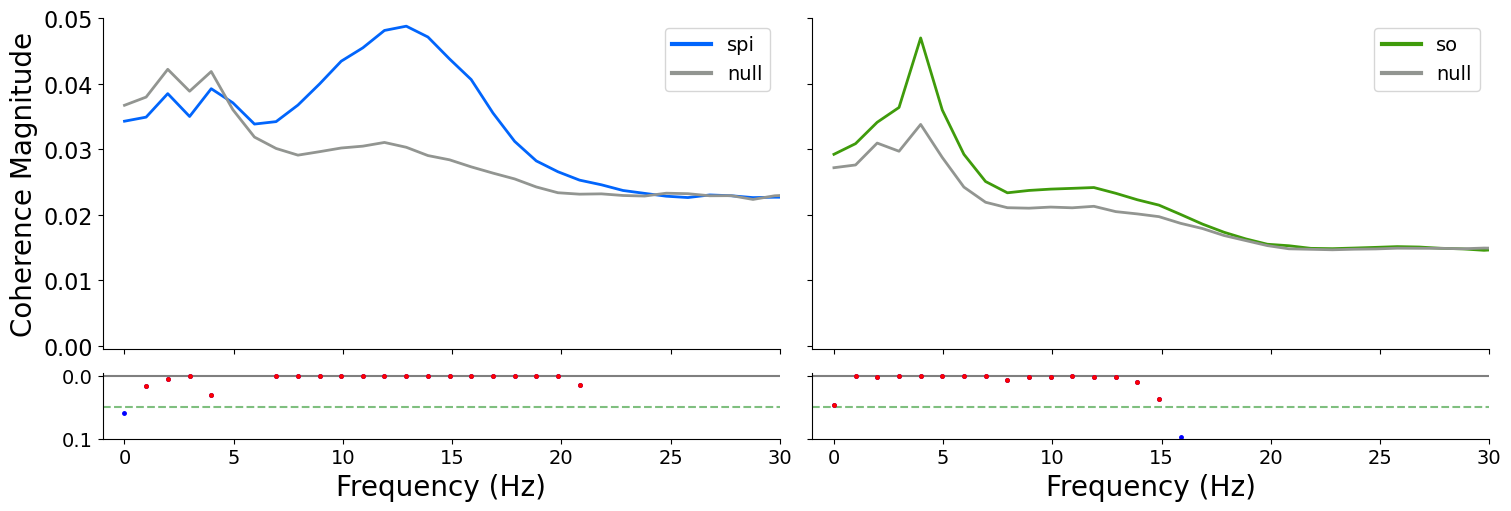

In [239]:
color_dict = {"spi-peak": "#0165fc", "so-peak": "#3f9b0b", "nrem-null": "#840000"}
freq_ind = 43
fig, axs = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(15, 5),
    height_ratios=[5, 1],
    sharex=True,
    sharey="row",
    constrained_layout=True,
)
for enum, (ax, key) in enumerate(zip(axs[0, :].ravel(), ["spi", "so"])):
    tmp_data = plot_df.loc[idx[key, :freq_ind, "peak"], :]
    tmp_null = plot_df.loc[idx[key, :freq_ind, "null"], :]
    p_vals = {
        float(f): f_data["p_value"]
        for f, f_data in stat_res[key].items()
        if f_data["model"].converged
    }
    # tmp_data = np.array(data["coherence"])[0, 0, :freq_ind, 0, 1:]
    # tmp_null = np.array(null["coherence"])[0, 0, :freq_ind, 0, 1:]
    # res = stats.ttest_rel(tmp_data, tmp_null, axis=-1)
    # reject, corr_ps, _, _ = sm.stats.multipletests(res.pvalue, method="bonferroni")
    # tmp_freq = data["frequency"][0][:freq_ind]
    tmp_freq = tmp_data.index.get_level_values("frequency").unique()
    ax.plot(
        tmp_freq,
        tmp_data.values,
        # np.nanmean(tmp_data, axis=-1),
        color=color_dict[f"{key}-peak"],
        label=key,
        lw=2,
    )
    # tmp_data_std = np.nanstd(tmp_data, axis=-1) / np.sqrt(tmp_data.shape[-1])
    # ax.fill_between(
    #     x=tmp_freq,
    #     y1=np.nanmean(tmp_data, axis=-1) - tmp_data_std,
    #     y2=np.nanmean(tmp_data, axis=-1) + tmp_data_std,
    #     color=color_dict[f"{key}-peak"],
    #     alpha=0.4,
    # )
    # tmp_null_std = np.nanstd(tmp_null, axis=-1) / np.sqrt(tmp_null.shape[-1])
    ax.plot(
        tmp_freq,
        tmp_null.values,
        # np.nanmean(tmp_null, axis=-1),
        color="#929591",
        label="null",
        lw=2,
    )
    # ax.fill_between(
    #     x=tmp_freq,
    #     y1=np.nanmean(tmp_null, axis=-1) - tmp_null_std,
    #     y2=np.nanmean(tmp_null, axis=-1) + tmp_null_std,
    #     color=color_dict[f"{key}-peak"],
    #     alpha=0.4,
    # )
    # ax.scatter(
    #     tmp_freq[reject],
    #     np.zeros_like(tmp_freq)[reject],
    #     c="k",
    #     marker="*",
    #     s=100,
    #     label="p<0.05 (Bonferroni)",
    # )
    leg = ax.legend()
    for line in leg.get_lines():
        line.set_linewidth(3)
    ax.set_xlim([-1, 30])
    ax.set_ylim([-0.0005, 0.05])
    # ax.set_yticks(np.arange(0, 0.021, 0.005))
    ax.xaxis.set_tick_params(labelsize=16)
    ax.yaxis.set_tick_params(labelsize=16)
    ax.spines[["top", "right"]].set_visible(False)
    ax = axs[1, enum]
    ax.axhline(0.0, ls="-", c="k", alpha=0.5)
    ax.axhline(0.05, ls="--", c="g", alpha=0.5)
    ax.plot(
        np.array(list(p_vals.keys()), dtype=float),
        np.array(list(p_vals.values())),
        ls="",
        marker=".",
        ms=5,
        c="b",
    )
    for f, p in p_vals.items():
        if p < 0.05:
            ax.plot(f, p, ls="", marker=".", ms=5, c="r")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_ylim([0.1, -0.005])
    ax.set_xlabel("Frequency (Hz)", fontsize=20)
axs[0, 0].set_ylabel("Coherence Magnitude", fontsize=20)

fig.savefig(
    Path(
        "/gpfs01/born/animal/DanielG/hypo_sleep/figures/coherence_figure_HYDO01-4_lmm.png"
    ),
    dpi=400,
    facecolor="white",
    transparent=False,
    bbox_inches="tight",
)

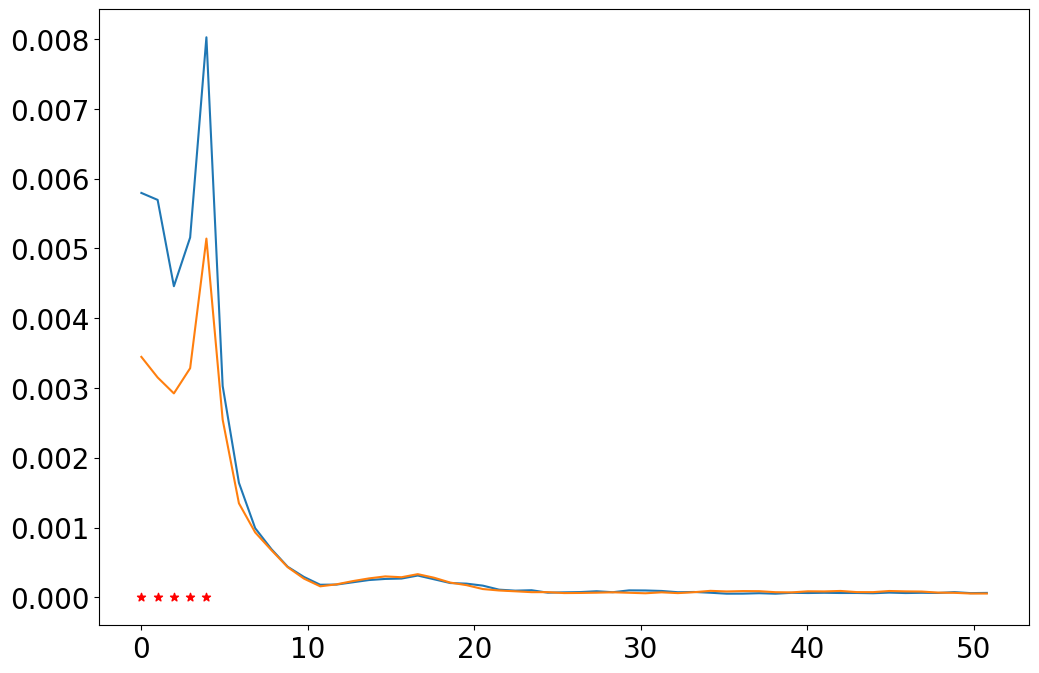

In [18]:
key = "so"
tmp = np.array(coh_dict_bootstrap_1[key]["coherence"])[0, 0, :53, 0, 1:]
tmp2 = np.array(coh_dict_null_bootstrap_1[key]["coherence"])[0, 0, :53, 0, 1:]
res = stats.ttest_rel(tmp, tmp2, axis=-1)
reject, corr_ps, _, _ = sm.stats.multipletests(res.pvalue, method="bonferroni")
tmp_freq = coh_dict_bootstrap_1[key]["frequency"][0][:53]
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(
    tmp_freq,
    np.array(coh_dict_bootstrap_1[key]["coherence"])[0, 0, :53, 0, 1:].mean(axis=-1),
)
ax.plot(
    tmp_freq,
    np.array(coh_dict_null_bootstrap_1[key]["coherence"])[0, 0, :53, 0, 1:].mean(
        axis=-1
    ),
)
ax.scatter(tmp_freq[reject], np.zeros_like(tmp_freq)[reject], marker="*", color="red")

In [ ]:
save_path = Path(data_path, "bootstrap_res")
coh_dict_bootstrap = {
    key: {"coherence": [], "phase": [], "frequency": []} for key in ["so", "spi"]
}
coh_dict_null_bootstrap = {
    key: {"coherence": [], "phase": [], "frequency": []} for key in ["so", "spi"]
}
trig_xr = {key: None for key in stack_xr_dict.keys()}
n_bootstrap = 100
n_samps = 250
for key, trig_dict in stack_xr_dict.items():
    tmp_xr = xr.concat([val for val in trig_dict.values()], dim="trial")
    trig_xr[key] = tmp_xr.assign_coords(trial=range(tmp_xr.sizes["trial"]))
for key in ["so"]:  #  "spi"]:
    trials = trig_xr[key].trial.values
    for i in range(n_bootstrap):
        tmp_trials = return_bootstrap_sample(trials, n_samps)
        tmp_trig_data = trig_xr[key].sel(trial=tmp_trials)

        mtm = Multitaper(
            tmp_trig_data.sel(time=slice(-0.5, 0.5)).transpose(
                "time", "trial", "channel"
            ),
            sampling_frequency=250,
            start_time=tmp_trig_data.time.values[0],
        )
        connectivity = Connectivity.from_multitaper(mtm)
        coherence = connectivity.coherence_magnitude()
        coh_dict_bootstrap[key]["coherence"].append(connectivity.coherence_magnitude())
        coh_dict_bootstrap[key]["phase"].append(connectivity.coherence_phase())
        coh_dict_bootstrap[key]["frequency"].append(connectivity.frequencies)
        mtm = Multitaper(
            tmp_trig_data.sel(time=slice(-2.5, -1.5)).transpose(
                "time", "trial", "channel"
            ),
            sampling_frequency=250,
            start_time=tmp_trig_data.time.values[0],
        )
        connectivity = Connectivity.from_multitaper(mtm)
        coherence = connectivity.coherence_magnitude()
        coh_dict_null_bootstrap[key]["coherence"].append(
            connectivity.coherence_magnitude()
        )
        coh_dict_null_bootstrap[key]["phase"].append(connectivity.coherence_phase())
        coh_dict_null_bootstrap[key]["frequency"].append(connectivity.frequencies)
        if ((i % 5 == 0) & (i != 0)) or (i == n_bootstrap - 1):
            np.savez(
                Path(save_path, f"bootstrap_results_{key}_{i:02d}.npz"),
                **{
                    k: np.concatenate(v, axis=0)
                    for k, v in coh_dict_bootstrap[key].items()
                },
            )
            np.savez(
                Path(save_path, f"bootstrap_results_null_{key}_{i:02d}.npz"),
                **{
                    k: np.concatenate(v, axis=0)
                    for k, v in coh_dict_null_bootstrap[key].items()
                },
            )
            print(f"Bootstrap iteration {i} completed and saved for trigger {key}")
            coh_dict_bootstrap[key] = {
                "coherence": [],
                "phase": [],
                "frequency": [],
            }
            coh_dict_null_bootstrap[key] = {
                "coherence": [],
                "phase": [],
                "frequency": [],
            }

Bootstrap iteration 5 completed and saved for trigger so
Bootstrap iteration 10 completed and saved for trigger so
Bootstrap iteration 15 completed and saved for trigger so
Bootstrap iteration 20 completed and saved for trigger so
Bootstrap iteration 25 completed and saved for trigger so
Bootstrap iteration 30 completed and saved for trigger so
Bootstrap iteration 35 completed and saved for trigger so
Bootstrap iteration 40 completed and saved for trigger so
Bootstrap iteration 45 completed and saved for trigger so
Bootstrap iteration 50 completed and saved for trigger so
Bootstrap iteration 55 completed and saved for trigger so
Bootstrap iteration 60 completed and saved for trigger so
Bootstrap iteration 65 completed and saved for trigger so
Bootstrap iteration 70 completed and saved for trigger so
Bootstrap iteration 5 completed and saved for trigger spi
Bootstrap iteration 10 completed and saved for trigger spi
Bootstrap iteration 15 completed and saved for trigger spi
Bootstrap ite

In [6]:
## To load/append to remaining dict
load_dict = {key: {target: {} for target in ["real", "null"]} for key in ["so", "spi"]}
steps = np.arange(0, 71, step=5)[1:]
for key in ["spi", "so"]:
    for target in ["real", "null"]:
        path_insert = "_null" if target == "null" else ""
        load_dict[key][target] = {
            "coherence": [],
            "phase": [],
            "frequency": [],
        }
        for step in steps:
            with np.load(
                Path(
                    data_path,
                    "bootstrap_res",
                    f"bootstrap_results{path_insert}_{key}_{step:02d}.npz",
                ),
                allow_pickle=True,
            ) as data:
                for k, v in data.items():
                    load_dict[key][target][k].append(v)
for event, target_data in load_dict.items():
    for target, data in target_data.items():
        #         dict_target = (
        #             coh_dict_bootstrap if target == "real" else coh_dict_null_bootstrap
        #         )
        for k, v in data.items():
            if len(v) > 0:
                #             if not isinstance(dict_target[event][k], np.ndarray):
                #                 tmp = np.stack(dict_target[event][k], axis=0)
                #             else:
                #                 tmp = dict_target[event][k]
                if k != "frequency":
                    load_dict[event][target][k] = np.concatenate(v, axis=0)

In [74]:
res = stats.ttest_ind(
    load_dict["spi"]["real"]["coherence"][:, :53, 0, :],
    load_dict["spi"]["null"]["coherence"][:, :53, 0, :],
    equal_var=False,
    axis=0,
)
orig_shape = res.pvalue.shape
reject, corr_ps, _, _ = sm.stats.multipletests(
    res.pvalue.flatten(),
    method="bonferroni",
)
reject = reject.reshape(orig_shape)
corr_ps = corr_ps.reshape(orig_shape)

In [ ]:
res = stats.ttest_ind(
    load_dict[key]["real"]["coherence"][:, :53, 0, :].mean(axis=-1),
    load_dict[key]["null"]["coherence"][:, :53, 0, :].mean(axis=-1),
    equal_var=False,
    axis=0,
)
orig_shape = res.pvalue.shape
reject, corr_ps, _, _ = sm.stats.multipletests(
    res.pvalue.flatten(),
    method="bonferroni",
)
reject = reject.reshape(orig_shape)
corr_ps = corr_ps.reshape(orig_shape)

/tmp/ipykernel_12690/1481984726.py:24: RuntimeWarning: Mean of empty slice
  np.nanmean(load_dict[key]["real"]["coherence"], axis=0)[:53, 0, :], axis=-1
/tmp/ipykernel_12690/1481984726.py:29: RuntimeWarning: Mean of empty slice
  np.nanmean(load_dict[key]["null"]["coherence"], axis=0)[:53, 0, :], axis=-1
/tmp/ipykernel_12690/1481984726.py:43: RuntimeWarning: Mean of empty slice
  np.nanmean(load_dict[key]["real"]["coherence"], axis=0)[:53, 0, :],


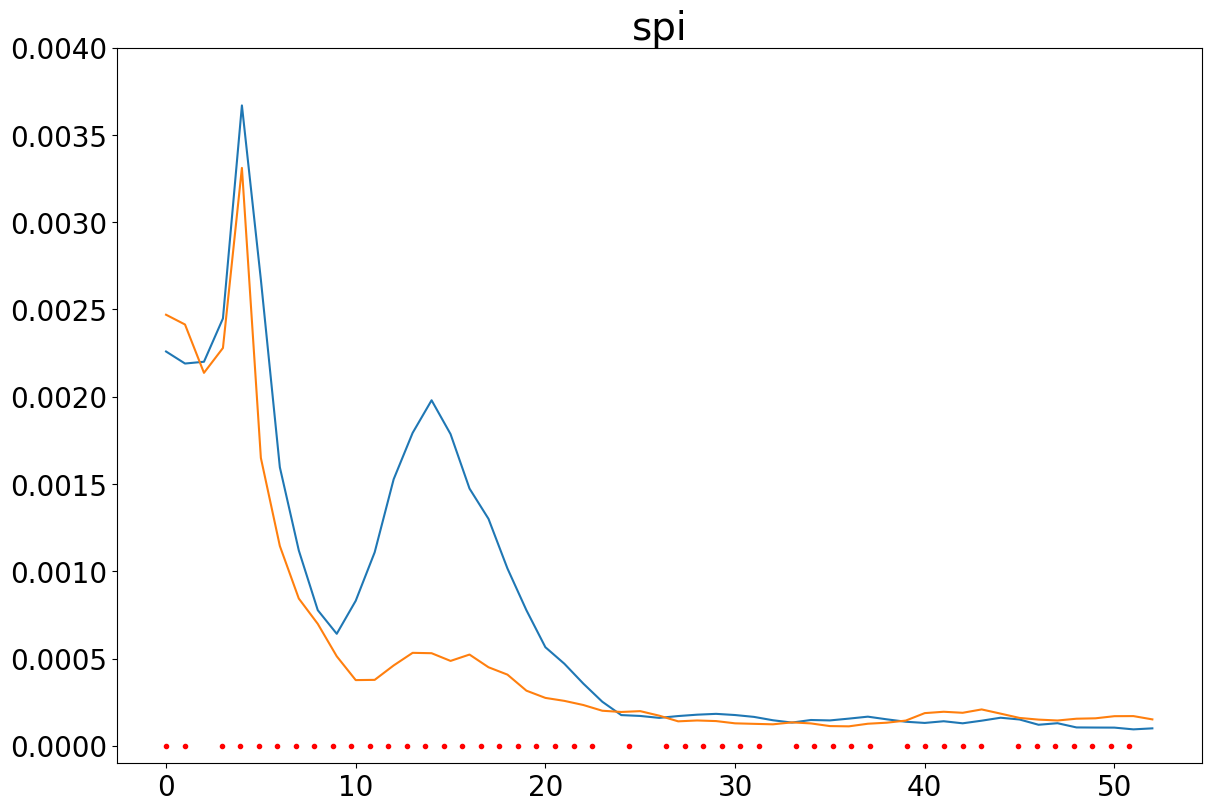

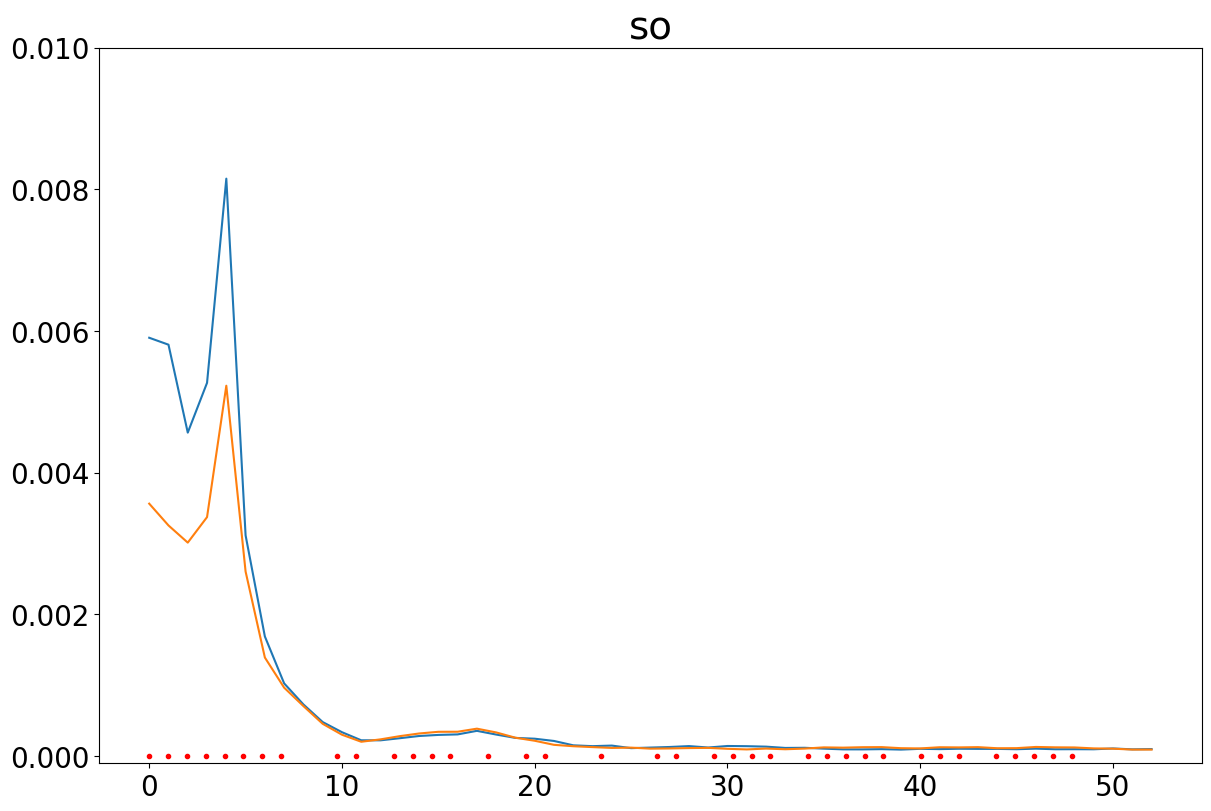

In [31]:
for key in ["spi", "so"]:
    res = stats.ttest_ind(
        np.nanmean(load_dict[key]["real"]["coherence"][:, :53, 0, :], axis=-1),
        np.nanmean(load_dict[key]["null"]["coherence"][:, :53, 0, :], axis=-1),
        equal_var=False,
        axis=0,
    )
    orig_shape = res.pvalue.shape
    reject, corr_ps, _, _ = sm.stats.multipletests(
        res.pvalue.flatten(),
        method="bonferroni",
    )
    reject = reject.reshape(orig_shape)
    corr_ps = corr_ps.reshape(orig_shape)
    freq = load_dict[key]["real"]["frequency"][0][:53]
    fig, ax = plt.subplots(
        figsize=(12, 8),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    ax.plot(
        np.nanmean(
            np.nanmean(load_dict[key]["real"]["coherence"], axis=0)[:53, 0, :], axis=-1
        )
    )
    ax.plot(
        np.nanmean(
            np.nanmean(load_dict[key]["null"]["coherence"], axis=0)[:53, 0, :], axis=-1
        )
    )
    ax.scatter(
        freq[reject],
        np.zeros_like(freq)[reject],
        marker=".",
        c="r",
    )
    ax.set_ylim(
        [
            -0.0001,
            np.ceil(
                np.nanmean(
                    np.nanmean(load_dict[key]["real"]["coherence"], axis=0)[:53, 0, :],
                    axis=-1,
                ).max()
                * 500
            )
            / 500,
        ]
    )
    ax.set_title(key)

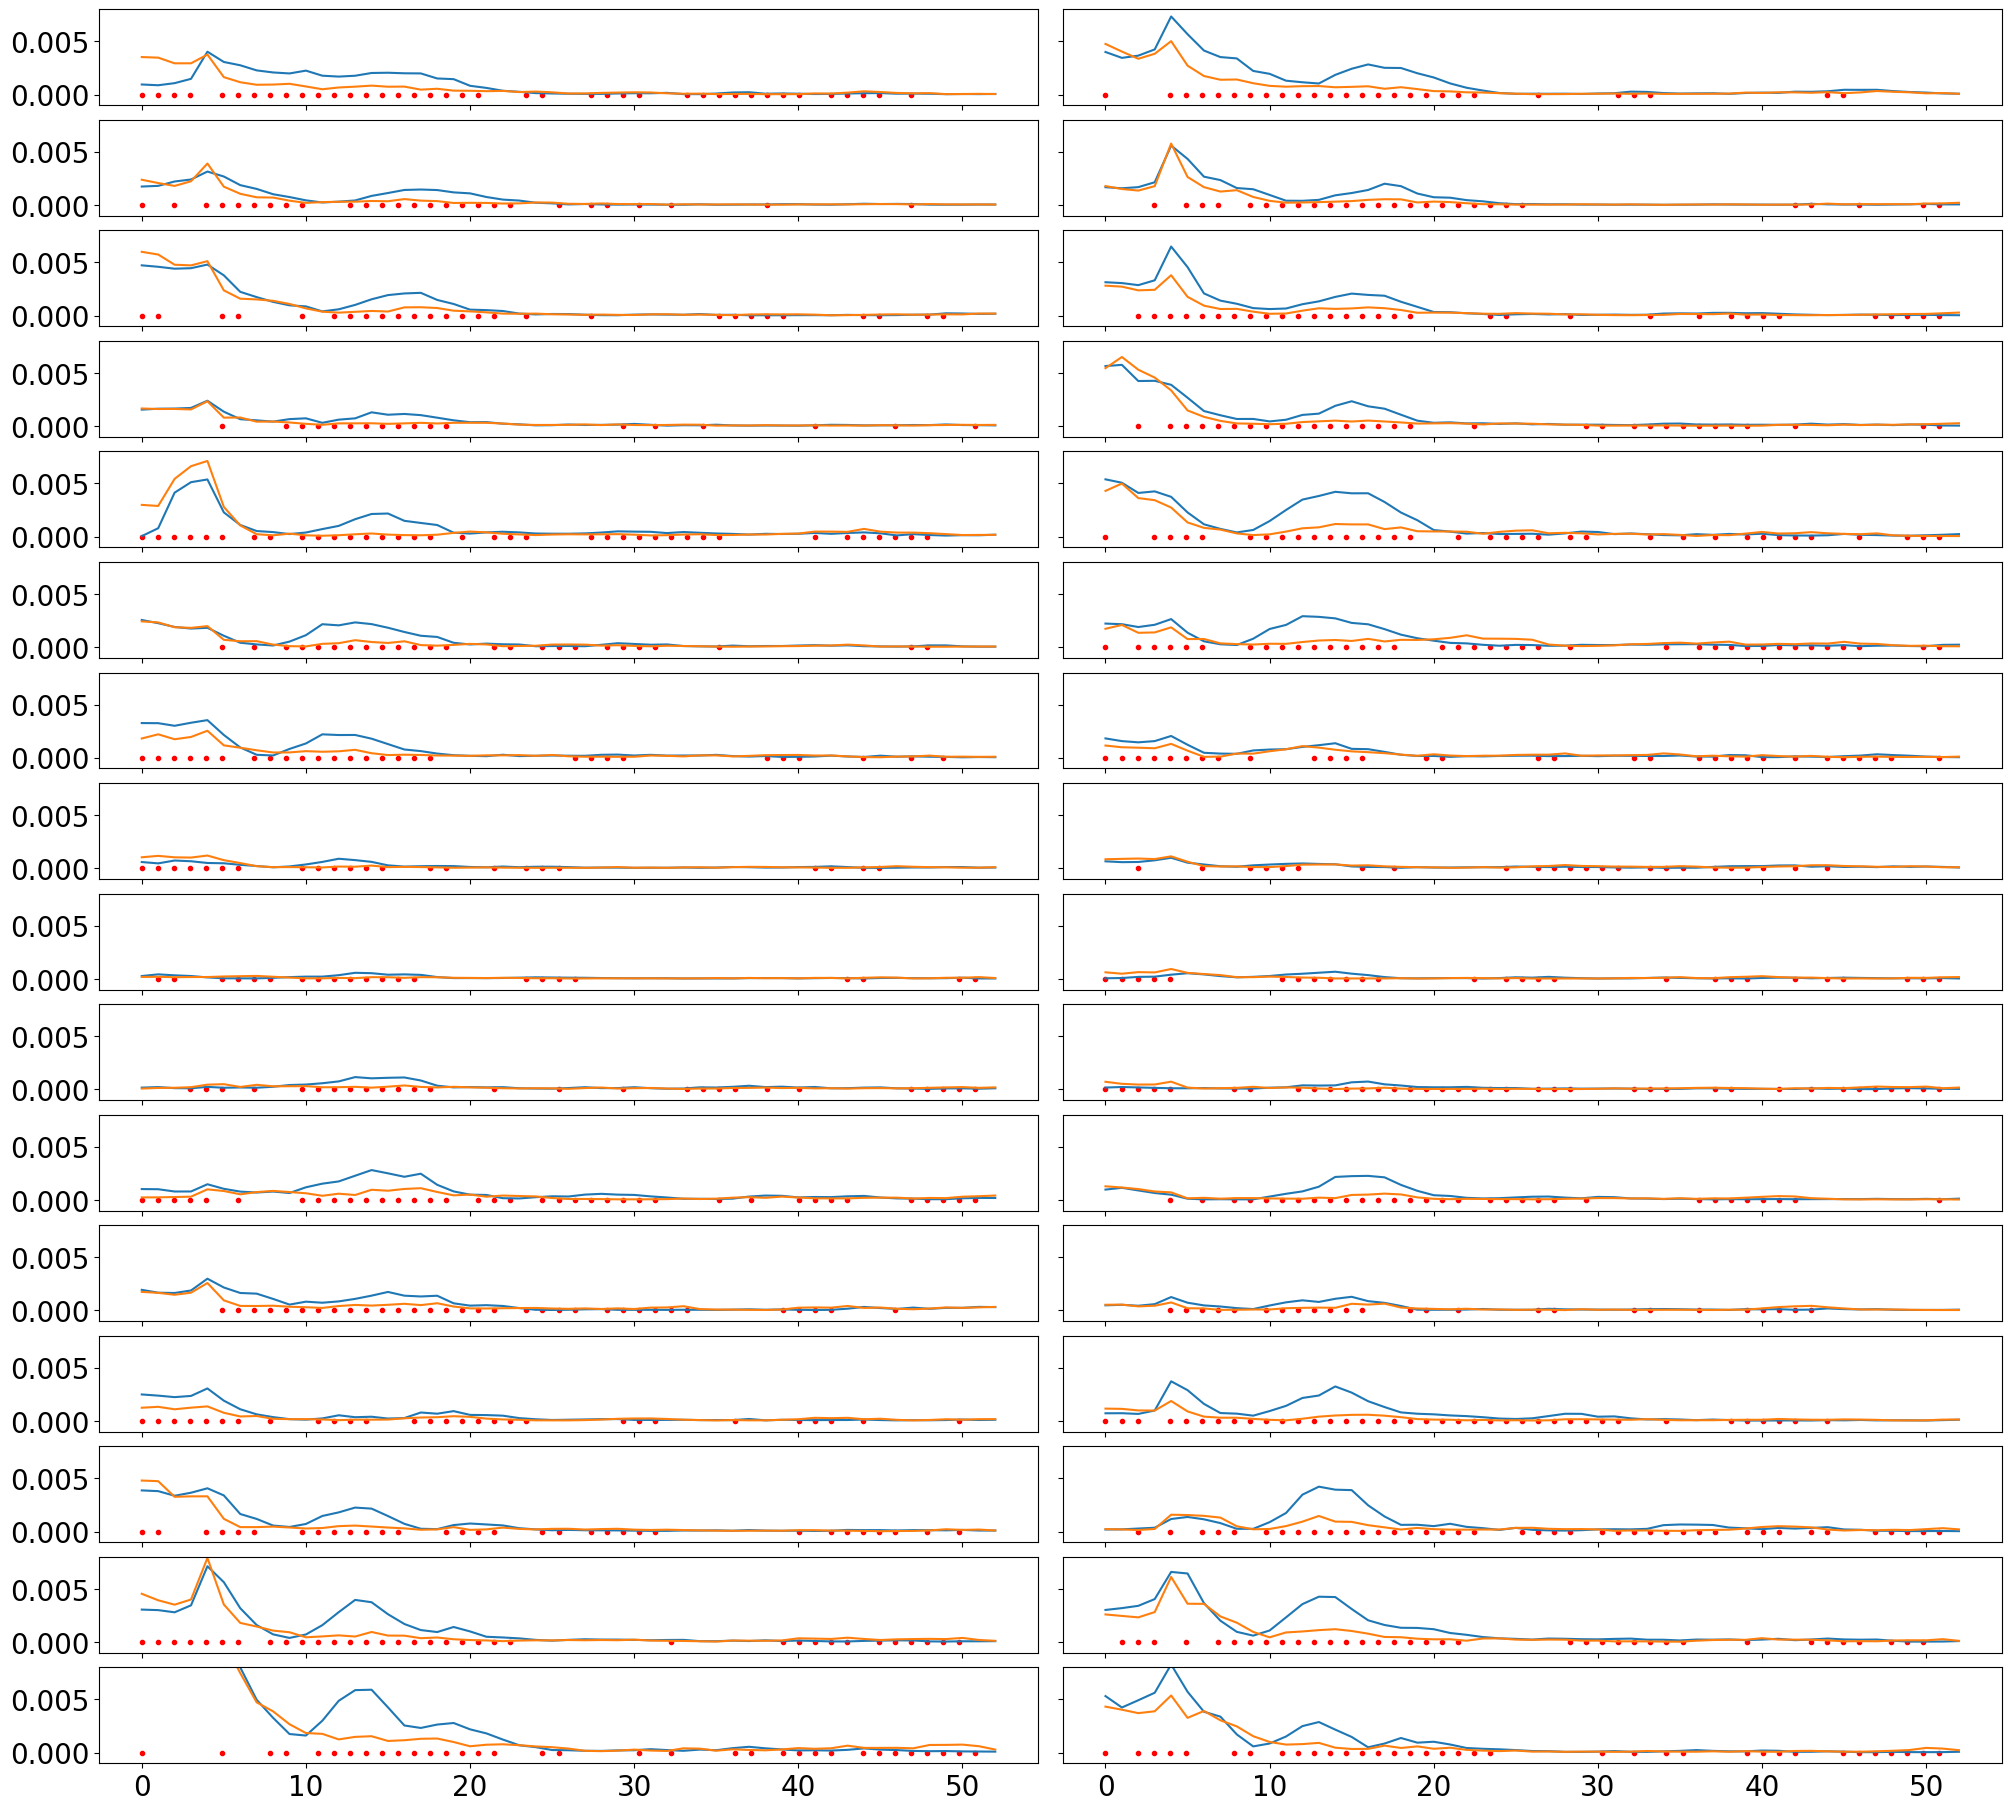

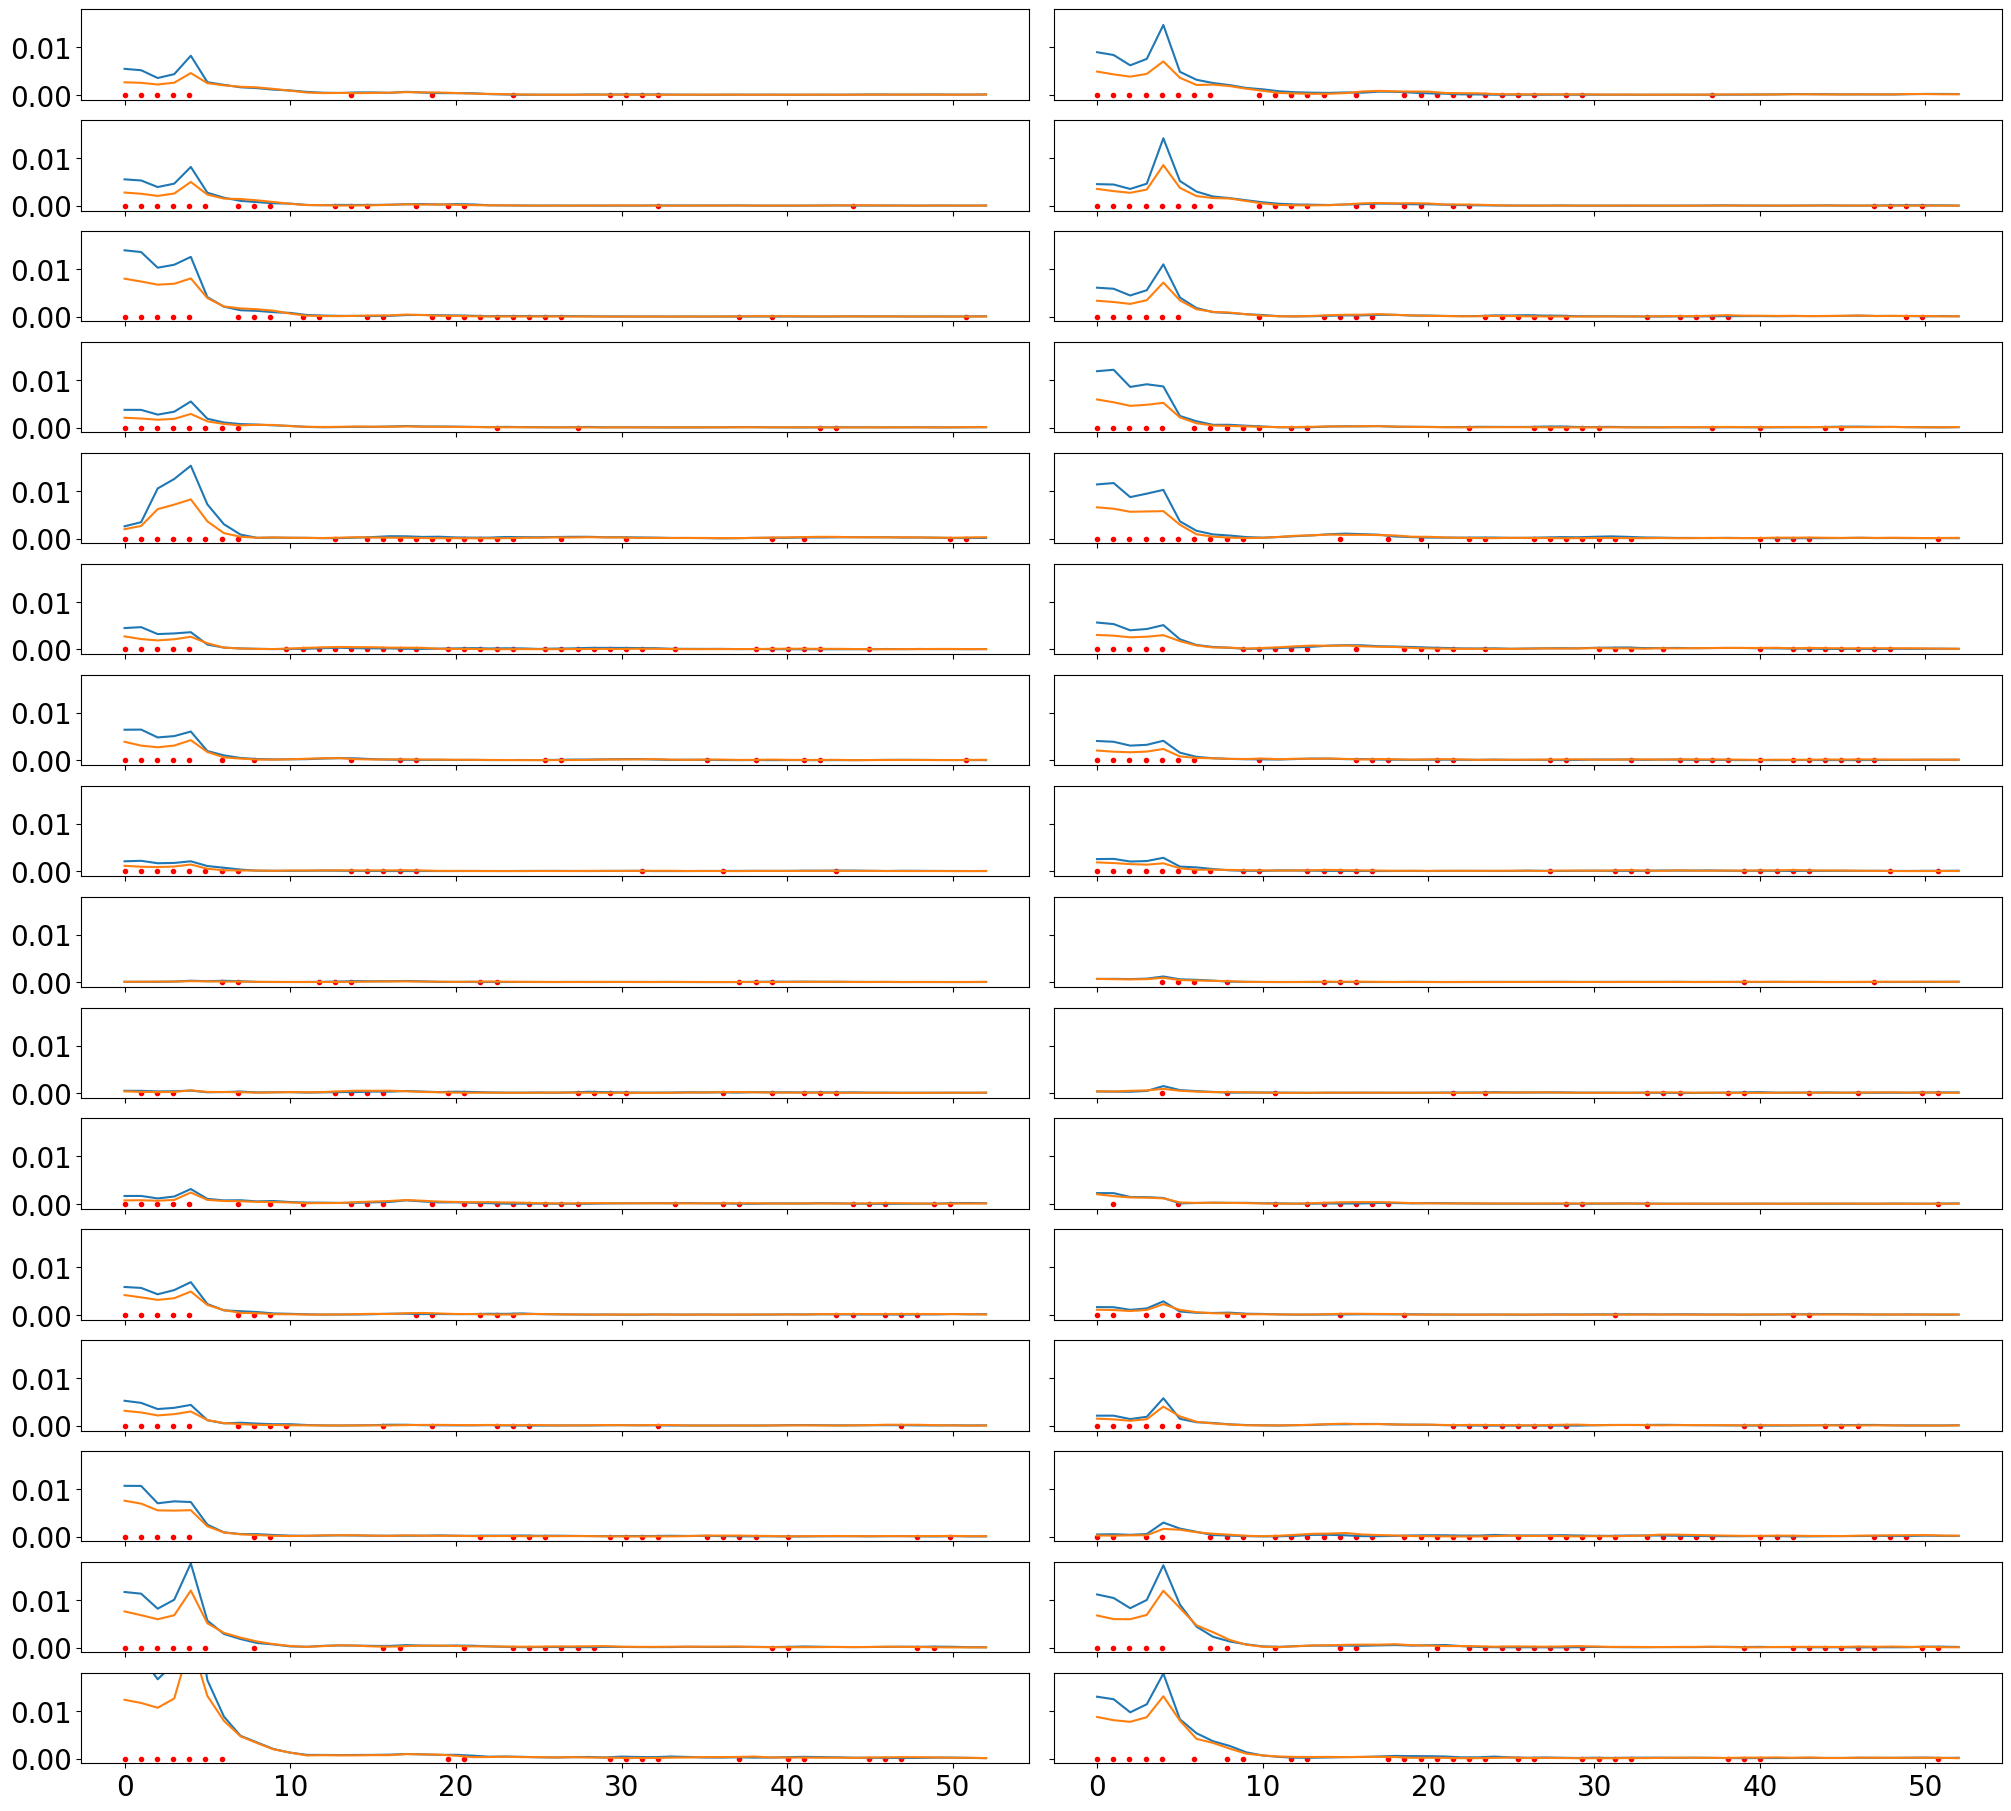

In [ ]:
for key in ["spi", "so"]:
    res = stats.ttest_ind(
        load_dict[key]["real"]["coherence"][:, :53, 0, :].mean(axis=-1),
        load_dict[key]["null"]["coherence"][:, :53, 0, :].mean(axis=-1),
        equal_var=False,
        axis=0,
    )
    orig_shape = res.pvalue.shape
    reject, corr_ps, _, _ = sm.stats.multipletests(
        res.pvalue.flatten(),
        method="bonferroni",
    )
    reject = reject.reshape(orig_shape)
    corr_ps = corr_ps.reshape(orig_shape)
    freq = load_dict[key]["real"]["frequency"][0][:53]
    fig, axs = plt.subplots(
        nrows=16,
        ncols=2,
        figsize=(20, 18),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    for ind, ax in enumerate(axs.ravel()):
        ax.plot(load_dict[key]["real"]["coherence"].mean(axis=0)[:53, 0, ind + 1])
        ax.plot(load_dict[key]["null"]["coherence"].mean(axis=0)[:53, 0, ind + 1])
        ax.scatter(
            freq[reject[:, ind + 1]],
            np.zeros_like(freq)[reject[:, ind + 1]],
            marker=".",
            c="r",
        )
        ax.set_ylim(
            [
                -0.001,
                np.round(
                    load_dict[key]["real"]["coherence"]
                    .mean(axis=0)[:53, 0, ind + 1]
                    .max(),
                    3,
                ),
            ]
        )

In [ ]:
coh_dict = {
    key: {"conn": [], "coherence": [], "phase": [], "frequency": []}
    for key in ["so", "spi"]
}
coh_dict_null = {
    key: {"conn": [], "coherence": [], "phase": [], "frequency": []}
    for key in ["so", "spi"]
}
for key, trig_dict in stack_xr_dict.items():
    trig_xr = xr.concat([val for val in trig_dict.values()], dim="trial")
    trig_xr = trig_xr.assign_coords(trial=range(trig_xr.sizes["trial"]))
    mtm = Multitaper(
        trig_xr.sel(time=slice(-0.5, 0.5)).transpose("time", "trial", "channel"),
        sampling_frequency=250,
        start_time=trig_xr.time.values[0],
    )
    connectivity = Connectivity.from_multitaper(mtm)
    coherence = connectivity.coherence_magnitude()
    coh_dict[key]["conn"].append(connectivity)
    coh_dict[key]["coherence"].append(connectivity.coherence_magnitude())
    coh_dict[key]["phase"].append(connectivity.coherence_phase())
    coh_dict[key]["frequency"].append(connectivity.frequencies)
    mtm = Multitaper(
        trig_xr.sel(time=slice(-2.5, -1.5)).transpose("time", "trial", "channel"),
        sampling_frequency=250,
        start_time=trig_xr.time.values[0],
    )
    connectivity = Connectivity.from_multitaper(mtm)
    coherence = connectivity.coherence_magnitude()
    coh_dict_null[key]["conn"].append(connectivity)
    coh_dict_null[key]["coherence"].append(connectivity.coherence_magnitude())
    coh_dict_null[key]["phase"].append(connectivity.coherence_phase())
    coh_dict_null[key]["frequency"].append(connectivity.frequencies)

: 

In [ ]:
coh_dict = {
    key: {
        date: {"conn": [], "coherence": [], "phase": [], "frequency": []}
        for date in stack_xr_dict[key].keys()
    }
    for key in ["so", "spi"]
}
coh_dict_null = {
    key: {
        date: {"conn": [], "coherence": [], "phase": [], "frequency": []}
        for date in stack_xr_dict[key].keys()
    }
    for key in ["so", "spi"]
}
for key, trig_dict in stack_xr_dict.items():
    for date, val in trig_dict.items():
        mtm = Multitaper(
            val.sel(time=slice(-0.5, 0.5)).transpose("time", "trial", "channel"),
            sampling_frequency=250,
            start_time=val.time.values[0],
        )
        connectivity = Connectivity.from_multitaper(mtm)
        coherence = connectivity.coherence_magnitude()
        coh_dict[key][date]["conn"].append(connectivity)
        coh_dict[key][date]["coherence"].append(connectivity.coherence_magnitude())
        coh_dict[key][date]["phase"].append(connectivity.coherence_phase())
        coh_dict[key][date]["frequency"].append(connectivity.frequencies)
        mtm = Multitaper(
            val.sel(time=slice(-2.5, -1.5)).transpose("time", "trial", "channel"),
            sampling_frequency=250,
            start_time=val.time.values[0],
        )
        connectivity = Connectivity.from_multitaper(mtm)
        coherence = connectivity.coherence_magnitude()
        coh_dict_null[key][date]["conn"].append(connectivity)
        coh_dict_null[key][date]["coherence"].append(connectivity.coherence_magnitude())
        coh_dict_null[key][date]["phase"].append(connectivity.coherence_phase())
        coh_dict_null[key][date]["frequency"].append(connectivity.frequencies)

In [23]:
for (key1, val1), (key2, val2) in zip(coh_dict.items(), coh_dict_null.items()):
    coh_dict[key1]["coherence"] = np.stack(val1["coherence"], axis=0)
    coh_dict_null[key2]["coherence"] = np.stack(val2["coherence"], axis=0)
    coh_dict[key1]["phase"] = np.stack(val1["phase"], axis=0)
    coh_dict_null[key2]["phase"] = np.stack(val2["phase"], axis=0)
    coh_dict[key1]["frequency"] = np.stack(val1["frequency"], axis=0)
    coh_dict_null[key2]["frequency"] = np.stack(val2["frequency"], axis=0)

/tmp/ipykernel_3294838/3690321257.py:2: RuntimeWarning: Mean of empty slice
  ax.plot(np.nanmean(coh_dict["spi"]["coherence"], axis=0)[0, :51, 0, -1])
/tmp/ipykernel_3294838/3690321257.py:3: RuntimeWarning: Mean of empty slice
  ax.plot(np.nanmean(coh_dict_null["spi"]["coherence"], axis=0)[0, :51, 0, -1])


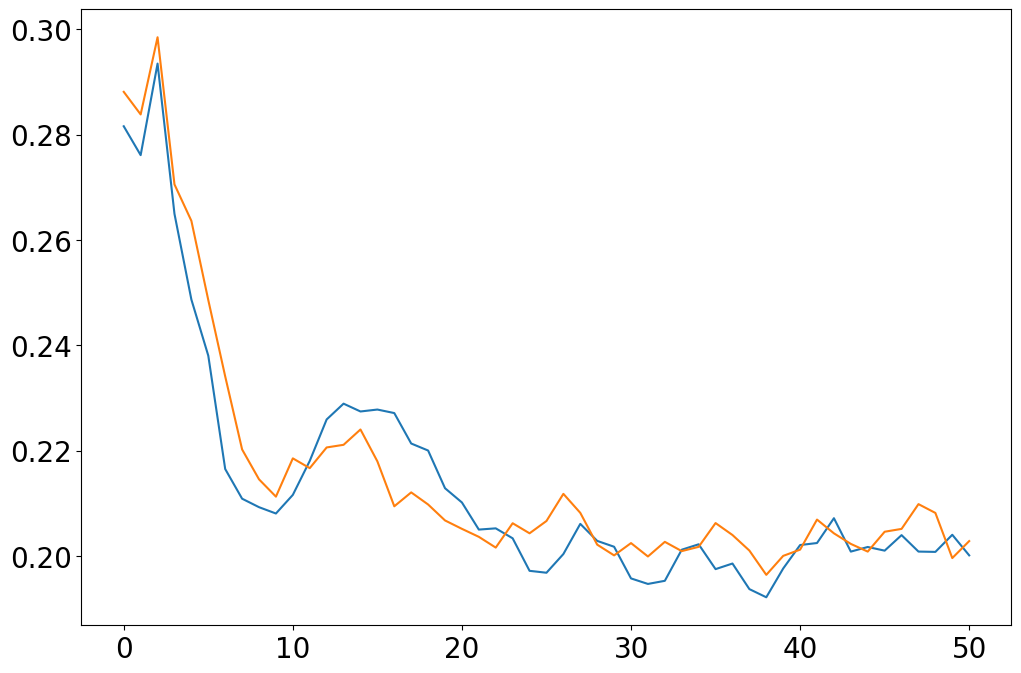

In [80]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(np.nanmean(coh_dict["spi"]["coherence"], axis=0)[0, :51, 0, -1])
ax.plot(np.nanmean(coh_dict_null["spi"]["coherence"], axis=0)[0, :51, 0, -1])

(<a list of 4 Line2D ticklines objects>,
 [Text(0.0, 0, '0°'), Text(1.5707963267948966, 0, '90°')])

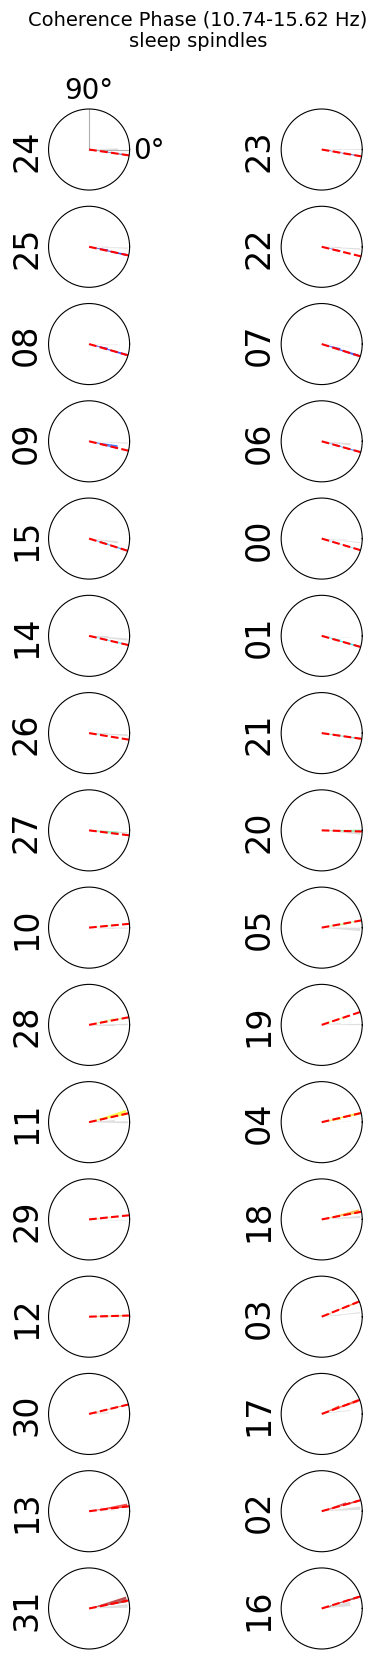

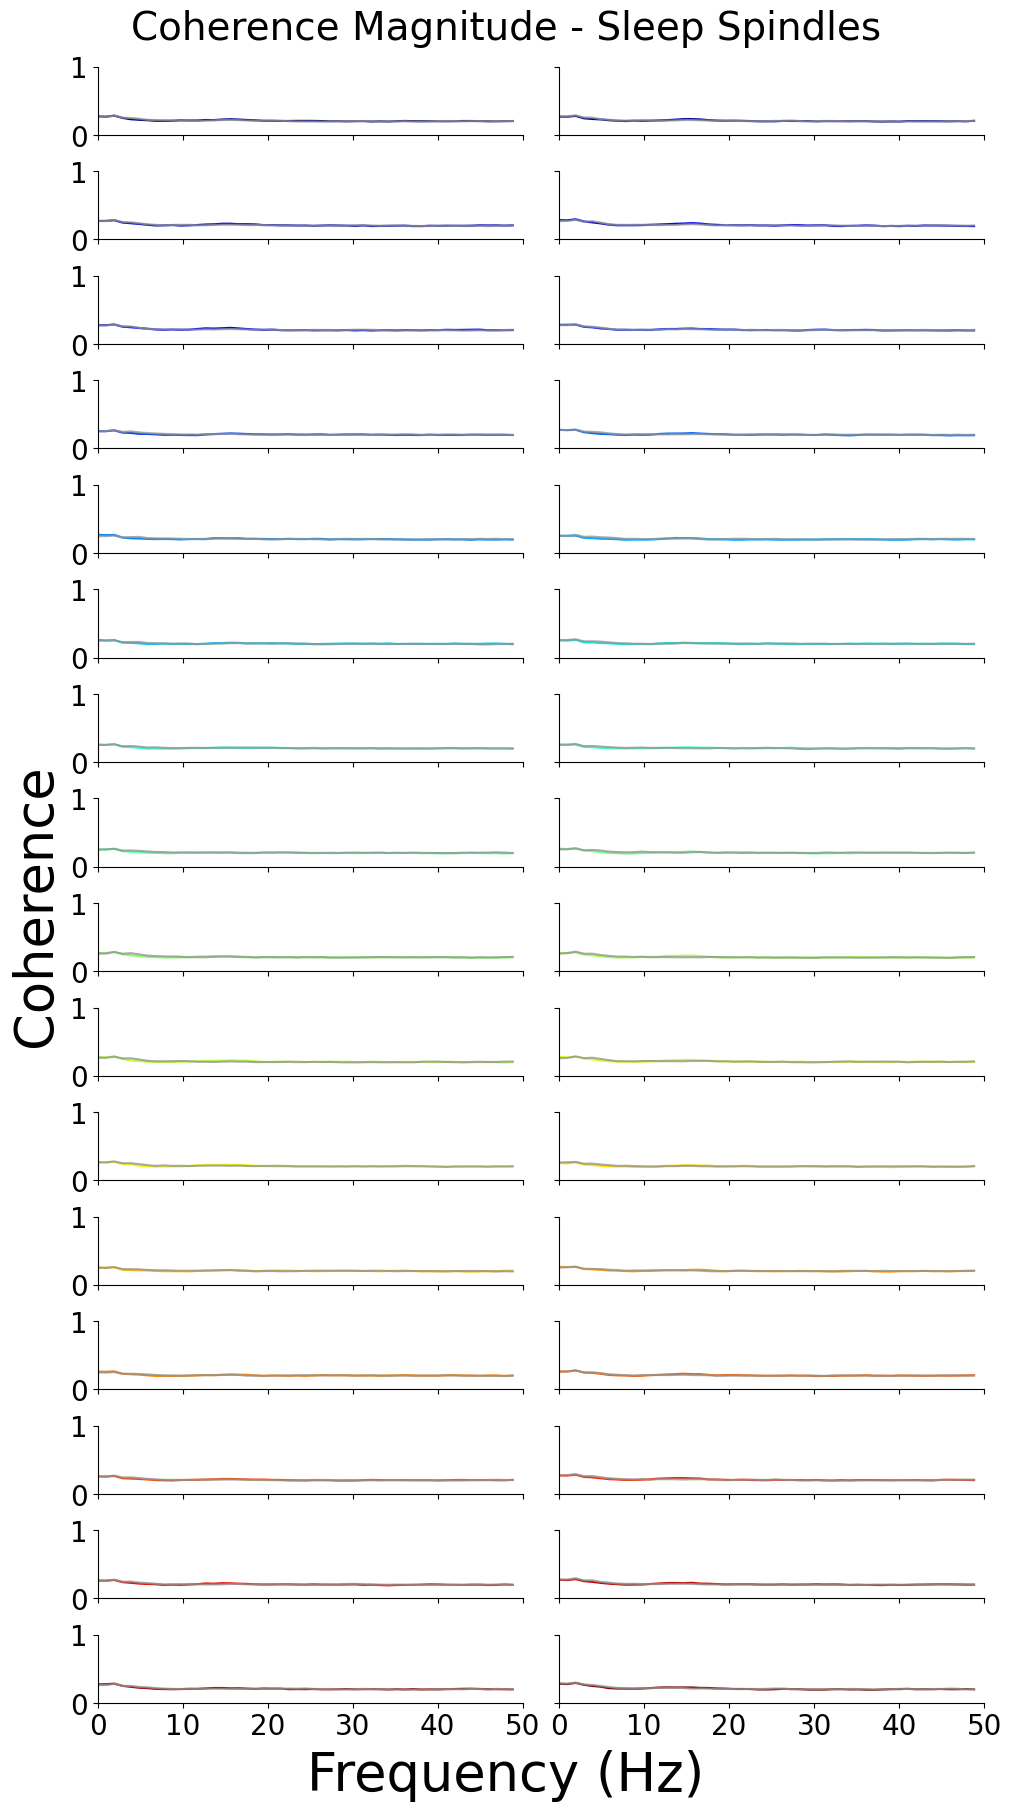

In [46]:
spi_freq_inds = np.where(
    (coh_dict["spi"]["frequency"][0] >= 10) & (coh_dict["spi"]["frequency"][0] <= 16)
)[0]
colors = plt.cm.jet(np.linspace(0, 1, len(depth_ordered_chs)))
mean_phase = []
fig1, axs1 = plt.subplots(
    nrows=16,
    ncols=2,
    figsize=(6, 20),
    # constrained_layout=True,
    subplot_kw={"polar": True},
)
fig1.subplots_adjust(wspace=0.001)
fig2, axs2 = plt.subplots(
    nrows=16,
    ncols=2,
    figsize=(10, 18),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
for ind, (ax1, ax2, ch) in enumerate(
    zip(axs1.ravel(), axs2.ravel(), stack_xr_dict["spi"].channel.values[2:])
):
    ax1.set_thetagrids(
        angles=[],
    )
    heights, bins, _ = ax1.hist(
        coh_dict["spi"]["phase"][:, 0, spi_freq_inds, 0, ind + 2].mean(axis=0),
        color=colors[ind],
        alpha=0.7,
        bins="fd",
    )
    ax1.axvline(
        np.mean(bins[np.argmax(heights) : np.argmax(heights) + 2]),
        color="red",
        ls="--",
    )
    mean_phase.append(np.mean(bins[np.argmax(heights) : np.argmax(heights) + 2]))
    heights, bins, _ = ax1.hist(
        coh_dict_null["spi"]["phase"][:, 0, spi_freq_inds, 0, ind + 2].mean(axis=0),
        color="#929591",
        alpha=0.3,
        bins="fd",
    )
    # phase = bins[np.argwhere(heights >= np.quantile(heights, 0.9)).flatten()].mean()
    # ax1.axvline(phase, color="red", ls="--")
    # mean_phase.append(phase)

    ax1.set_rticks([])
    ax1.set_ylabel(f"{int(ch):02d}")
    ax2.plot(
        coh_dict["spi"]["frequency"][0, :51],
        coh_dict["spi"]["coherence"][:, 0, :51, 0, ind + 2].mean(axis=0),
        color=colors[ind],
    )
    # ax3 = ax2.twinx()
    ax2.plot(
        coh_dict_null["spi"]["frequency"][0, :51],
        coh_dict_null["spi"]["coherence"][:, 0, :51, 0, ind + 2].mean(axis=0),
        color="#929591",
        alpha=0.8,
        ls="-",
    )
    # ax3.set_ylim([0, 0.05])
    ax2.spines[["top", "right"]].set_visible(False)
    ax2.set_ylim([0, 1])
    ax2.set_xlim([0, 50])
fig1.suptitle(
    f"Coherence Phase ({coh_dict["spi"]["frequency"][0,spi_freq_inds][0]:.02f}-{coh_dict["spi"]["frequency"][0, spi_freq_inds][-1]:.02f} Hz)\nsleep spindles",
    fontsize=14,
    y=0.93,
)
fig2.supylabel("Coherence")
fig2.supxlabel("Frequency (Hz)")
fig2.suptitle("Coherence Magnitude - Sleep Spindles")
axs1[0, 0].set_thetagrids(
    angles=[0, 90],
)
# fig1.tight_layout()

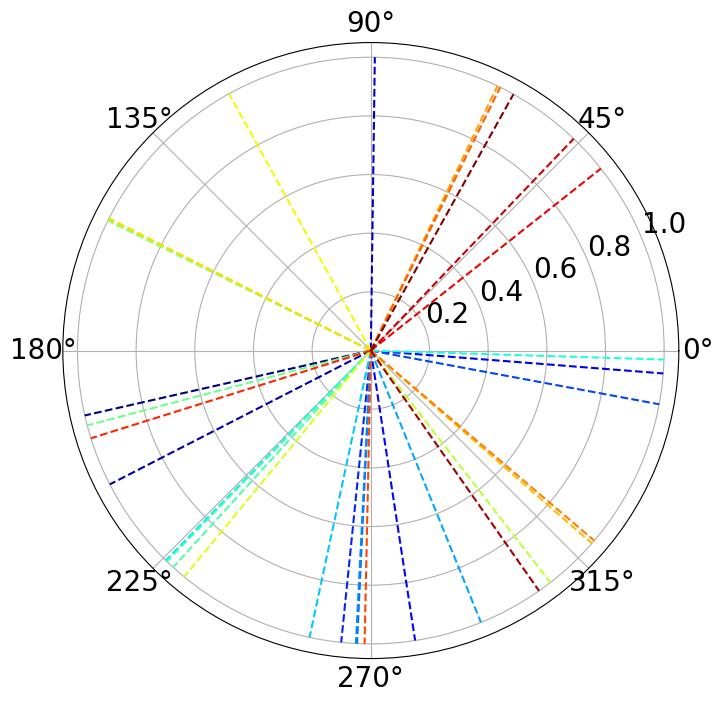

In [ ]:
# fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})
# ax.set_prop_cycle("color", colors)
# for val1 in mean_phase:
#     ax.plot([0, val1], [0, 1], ls="--")

(<a list of 4 Line2D ticklines objects>,
 [Text(0.0, 0, '0°'), Text(1.5707963267948966, 0, '90°')])

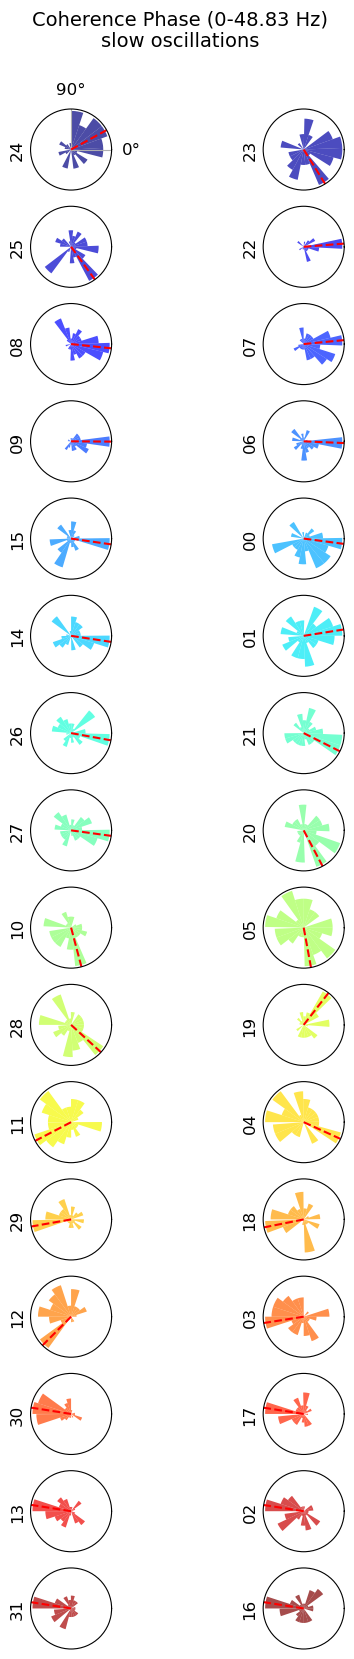

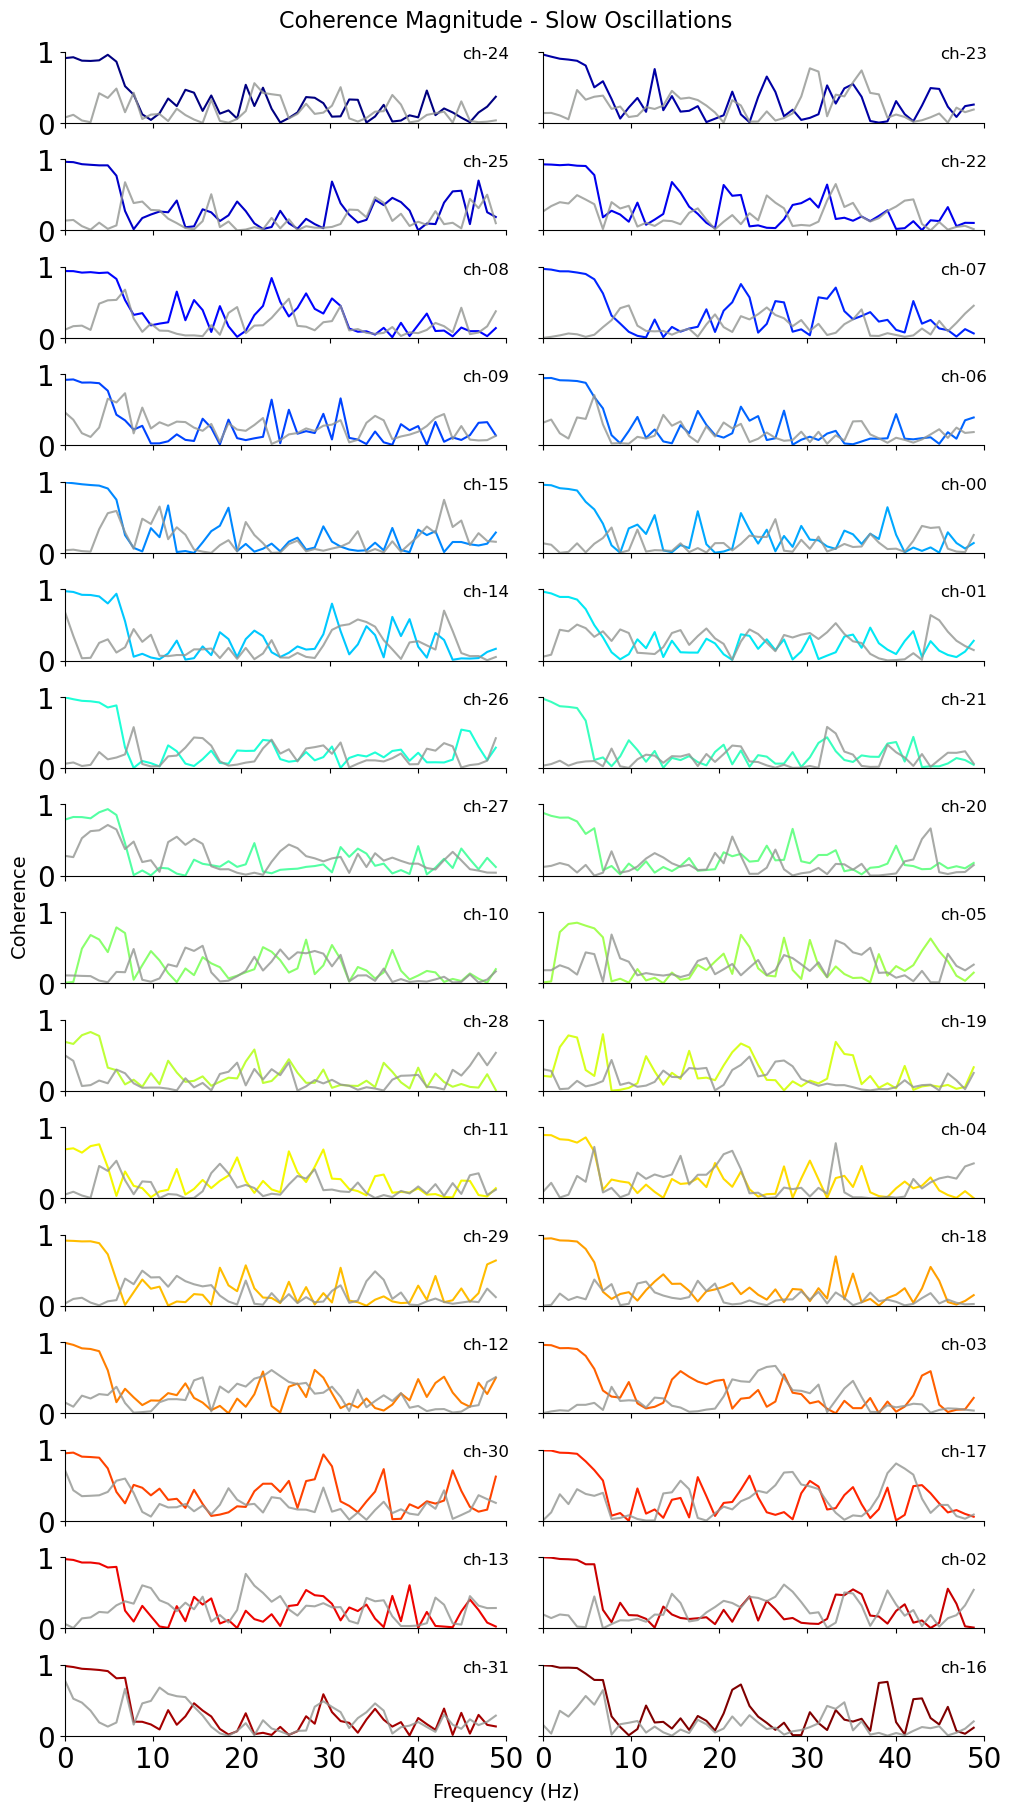

In [190]:
colors = plt.cm.jet(np.linspace(0, 1, len(depth_ordered_chs)))
mean_phase = []
fig1, axs1 = plt.subplots(
    nrows=16,
    ncols=2,
    figsize=(6, 20),
    # constrained_layout=True,
    subplot_kw={"polar": True},
)
fig1.subplots_adjust(wspace=0.001)
fig2, axs2 = plt.subplots(
    nrows=16,
    ncols=2,
    figsize=(10, 18),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
for ind, (ax1, ax2, ch) in enumerate(
    zip(axs1.ravel(), axs2.ravel(), stack_xr_dict["so"].channel.values[2:])
):
    ax1.set_thetagrids(
        angles=[],
    )
    heights, bins, _ = ax1.hist(
        coh_dict["so"]["phase"][0, :51, 0, ind + 2],
        color=colors[ind],
        alpha=0.7,
        bins=20,
    )
    # phase = bins[np.argwhere(heights >= np.quantile(heights, 0.9)).flatten()].mean()
    # ax1.axvline(phase, color="red", ls="--")
    # mean_phase.append(phase)
    ax1.axvline(
        np.mean(bins[np.argmax(heights) : np.argmax(heights) + 2]),
        color="red",
        ls="--",
    )
    mean_phase.append(np.mean(bins[np.argmax(heights) : np.argmax(heights) + 2]))
    ax1.set_rticks([])
    ax1.set_ylabel(f"{int(ch):02d}", fontsize=12)
    ax2.plot(
        coh_dict["so"]["frequency"][:51],
        coh_dict["so"]["coherence"][0, :51, 0, ind + 2],
        color=colors[ind],
        label=ch,
    )
    ax2.plot(
        coh_dict_null["so"]["frequency"][:51],
        coh_dict_null["so"]["coherence"][0, :51, 0, ind + 2],
        color="#929591",
        alpha=0.8,
        ls="-",
    )
    ax2.text(0.9, 0.9, f"ch-{int(ch):02d}", transform=ax2.transAxes, fontsize=12)
    ax2.spines[["top", "right"]].set_visible(False)
    ax2.set_ylim([0, 1])
    ax2.set_xlim([0, 50])
fig1.suptitle(
    f"Coherence Phase (0-{coh_dict["so"]["frequency"][:51][-1]:.02f} Hz)\nslow oscillations",
    fontsize=14,
    y=0.93,
)
fig2.supylabel("Coherence", fontsize=14)
fig2.supxlabel("Frequency (Hz)", fontsize=14)
fig2.suptitle("Coherence Magnitude - Slow Oscillations", fontsize=16)
axs1[0, 0].set_thetagrids(
    angles=[0, 90],
    fontsize=12,
)
# fig1.tight_layout()

/tmp/ipykernel_549079/3443227759.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig1.tight_layout()


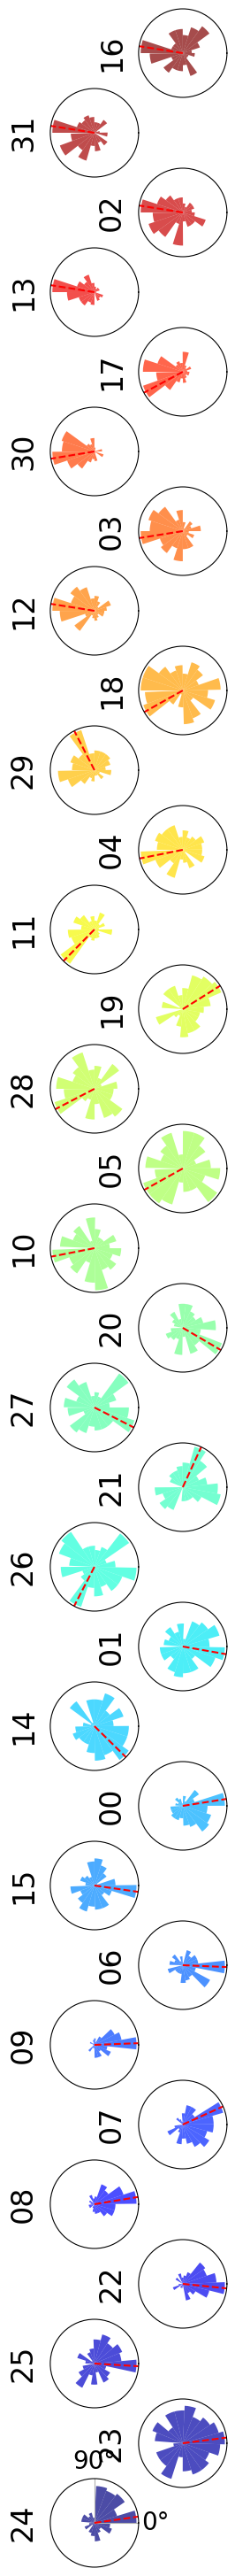

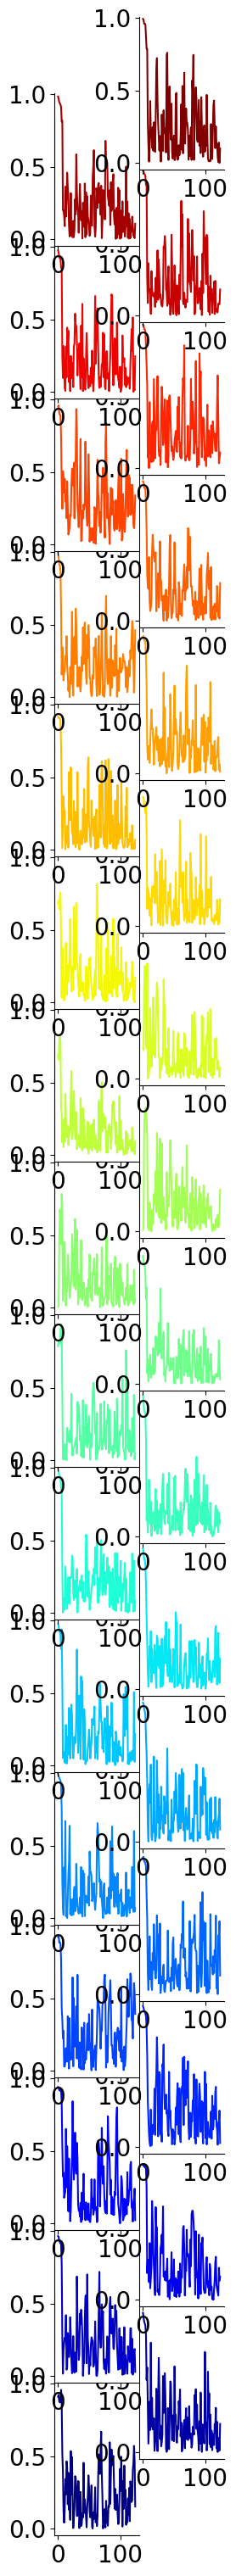

In [29]:
site_positions = []
for i in range(16):
    site_positions.append((0, i * 50))  # left column
    site_positions.append((25, i * 50 + 25))  # right column

site_positions = np.array(site_positions)

# Normalize for plotting layout
x_coords = site_positions[:, 0] / 25  # column index
y_coords = site_positions[:, 1] / 50

colors = plt.cm.jet(np.linspace(0, 1, len(depth_ordered_chs)))
mean_phase = []
fig1 = plt.figure(figsize=(10, 18))
fig2 = plt.figure(figsize=(10, 18))
all_axes = []
for ind, ch in enumerate(stack_xr_dict["spi"].channel.values[2:]):
    ax1 = fig1.add_axes(
        [
            0.1 + 0.1 * x_coords[ind],  # x position
            0.05 + 0.1 * y_coords[ind],  # y position
            0.1,
            0.1,
        ],
        polar=True,
    )
    ax2 = fig2.add_axes(
        [
            0.1 + 0.1 * x_coords[ind],  # x position
            0.05 + 0.1 * y_coords[ind],  # y position
            0.1,
            0.1,
        ],
        polar=False,
    )
    if ind == 0:
        ax1.set_thetagrids(
            angles=[0, 90],
        )
    else:
        ax1.set_thetagrids(
            angles=[],
        )
    heights, bins, _ = ax1.hist(
        coh_dict["so"]["phase"][0, :201, 0, ind + 2],
        color=colors[ind],
        alpha=0.7,
        bins=20,
    )
    # phase = bins[np.argwhere(heights > np.quantile(heights, 0.85)).flatten()].mean()
    # ax.axvline(phase, color="red", ls="--")
    ax1.axvline(
        np.mean(bins[np.argmax(heights) : np.argmax(heights) + 2]), color="red", ls="--"
    )
    mean_phase.append(np.mean(bins[np.argmax(heights) : np.argmax(heights) + 2]))
    ax1.set_rticks([])
    ax1.set_ylabel(f"{int(ch):02d}", labelpad=10)
    ax2.plot(
        coh_dict["so"]["frequency"][:201],
        coh_dict["so"]["coherence"][0, :201, 0, ind + 2],
        color=colors[ind],
    )
    ax2.spines[["top", "right"]].set_visible(False)
    all_axes.append(ax2)

# Link all to the first one
for ax in all_axes[1:]:
    ax.sharex(all_axes[0])
    ax.sharey(all_axes[0])

fig1.tight_layout()

In [193]:
from scipy import stats

In [266]:
freq_ind = 53
stats_dict = {}
for key in coh_dict.keys():
    stats_dict[key] = {}
    for ind, ch in enumerate(stack_xr_dict[key].channel.values[2:]):
        stats_dict[key][ch] = stats.ttest_ind_from_stats(
            mean1=coh_dict[key]["coherence"][:, :freq_ind, 0, ind + 2].mean(axis=0),
            std1=np.std(coh_dict[key]["coherence"][:, :freq_ind, 0, ind + 2], axis=0),
            nobs1=coh_dict[key]["coherence"].shape[0],
            mean2=coh_dict_null[key]["coherence"][:, :freq_ind, 0, ind + 2].mean(
                axis=0
            ),
            std2=np.std(
                coh_dict_null[key]["coherence"][:, :freq_ind, 0, ind + 2], axis=0
            ),
            nobs2=coh_dict_null[key]["coherence"].shape[0],
        )

In [265]:
coh_dict_null[key]["coherence"][:, :freq_ind, 0, ind + 2].shape

(2242, 53)

In [255]:
import statsmodels.api as sm

In [259]:
so_pvalues = np.array([ch_val.pvalue for ch_val in stats_dict["so"].values()])
spi_pvalues = np.array([ch_val.pvalue for ch_val in stats_dict["spi"].values()])

In [ ]:
sm.stats.multipletests(pvalues)

In [254]:
stats_dict["so"]["0"]

TtestResult(statistic=array([ 0.49025287,  0.66287773, -1.10268103, ..., -2.2682627 ,
       -3.02850182, -0.43313802]), pvalue=array([0.62498767, 0.50887537, 0.27271085, ..., 0.02537941, 0.00309969,
       0.6658115 ]), df=array([104., 104., 104., ..., 104., 104., 104.]))

Text(0.5, 0.01, 'Frequency (Hz)')

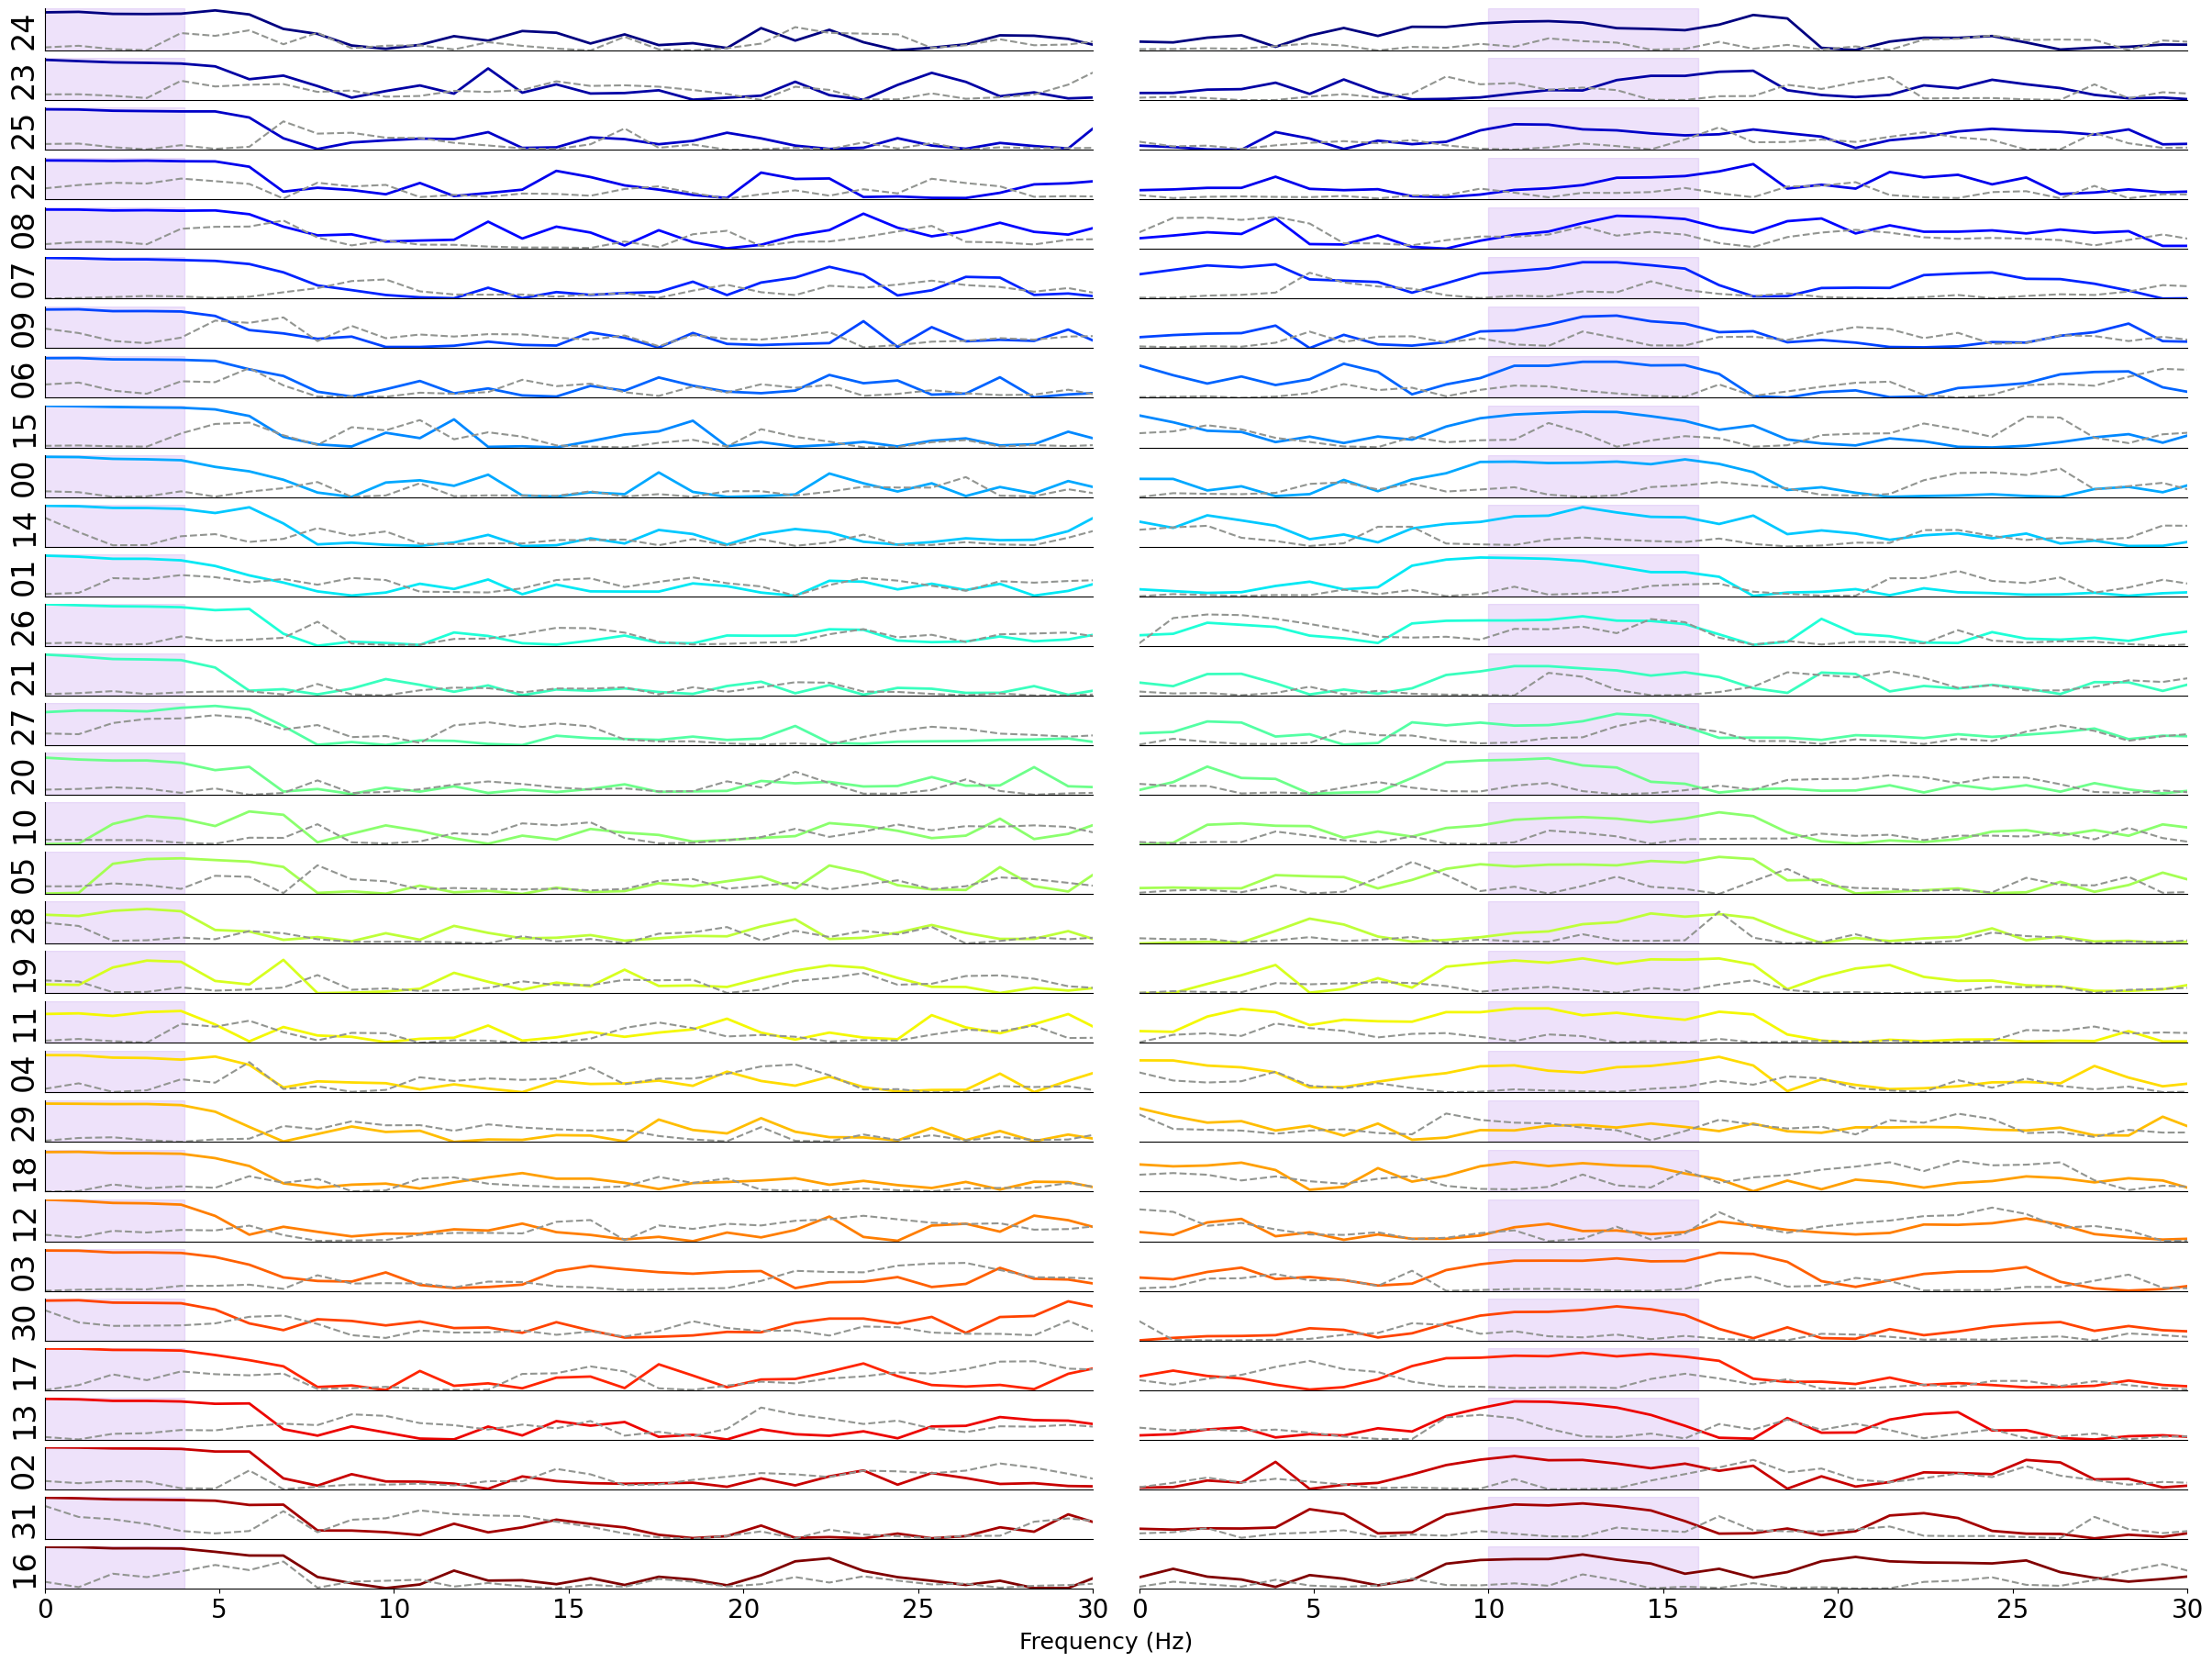

In [ ]:
fig, axs = plt.subplots(
    nrows=32,
    ncols=2,
    figsize=(24, 18),
    sharex=False,
    sharey=True,
    constrained_layout=True,
)
freq_ind = 53
colors = plt.cm.jet(np.linspace(0, 1, len(depth_ordered_chs)))
for ax_ind, (key, vals) in enumerate(coh_dict.items()):
    ax = axs[:, ax_ind]
    for ind, ch in enumerate(stack_xr_dict[key].channel.values[2:]):
        ax[ind].plot(
            vals["frequency"][:freq_ind],
            vals["coherence"][0, :freq_ind, 0, ind + 2],
            c=colors[ind],
            lw=2,
        )
        ax[ind].plot(
            coh_dict_null[key]["frequency"][:freq_ind],
            coh_dict_null[key]["coherence"][0, :freq_ind, 0, ind + 2],
            color="#929591",
            alpha=1,
            ls="--",
        )
        # ax[ind].plot(
        #     connectivity.frequencies[:201],
        #     vals["phase"][0, :201, 0, ind + 2]
        #     / vals["phase"][0, :201, 0, ind + 2].max(),
        #     c=colors[ind],
        #     ls="--",
        # )
        # if key == "so":
        #     ax[ind].axvspan(0, 4, alpha=0.3, color="#c79fef")
        # elif key == "spi":
        #     ax[ind].axvspan(10, 16, alpha=0.3, color="#c79fef")
        ax[ind].spines[["top", "right"]].set_visible(False)
        ax[ind].set_xlim([0, 30])  # vals["frequency"][:freq_ind][-1]])
        ax[ind].set_ylim([0, 1])
        axs[ind, 0].yaxis.set_tick_params(labelleft=False, left=False)
        axs[ind, 0].set_ylabel(f"{int(ch):02d}")
        if ind < len(axs[:, 0]) - 1:
            ax[ind].xaxis.set_tick_params(labelbottom=False, bottom=False)
            # ax[ind].spines[["bottom"]].set_visible(False)
for ax in axs[:, 1]:
    ax.spines[["left"]].set_visible(False)
    ax.yaxis.set_tick_params(labelleft=False, left=False)
fig.supxlabel("Frequency (Hz)", fontsize=18)

plotting
HYDO03
plotting
HYDO04


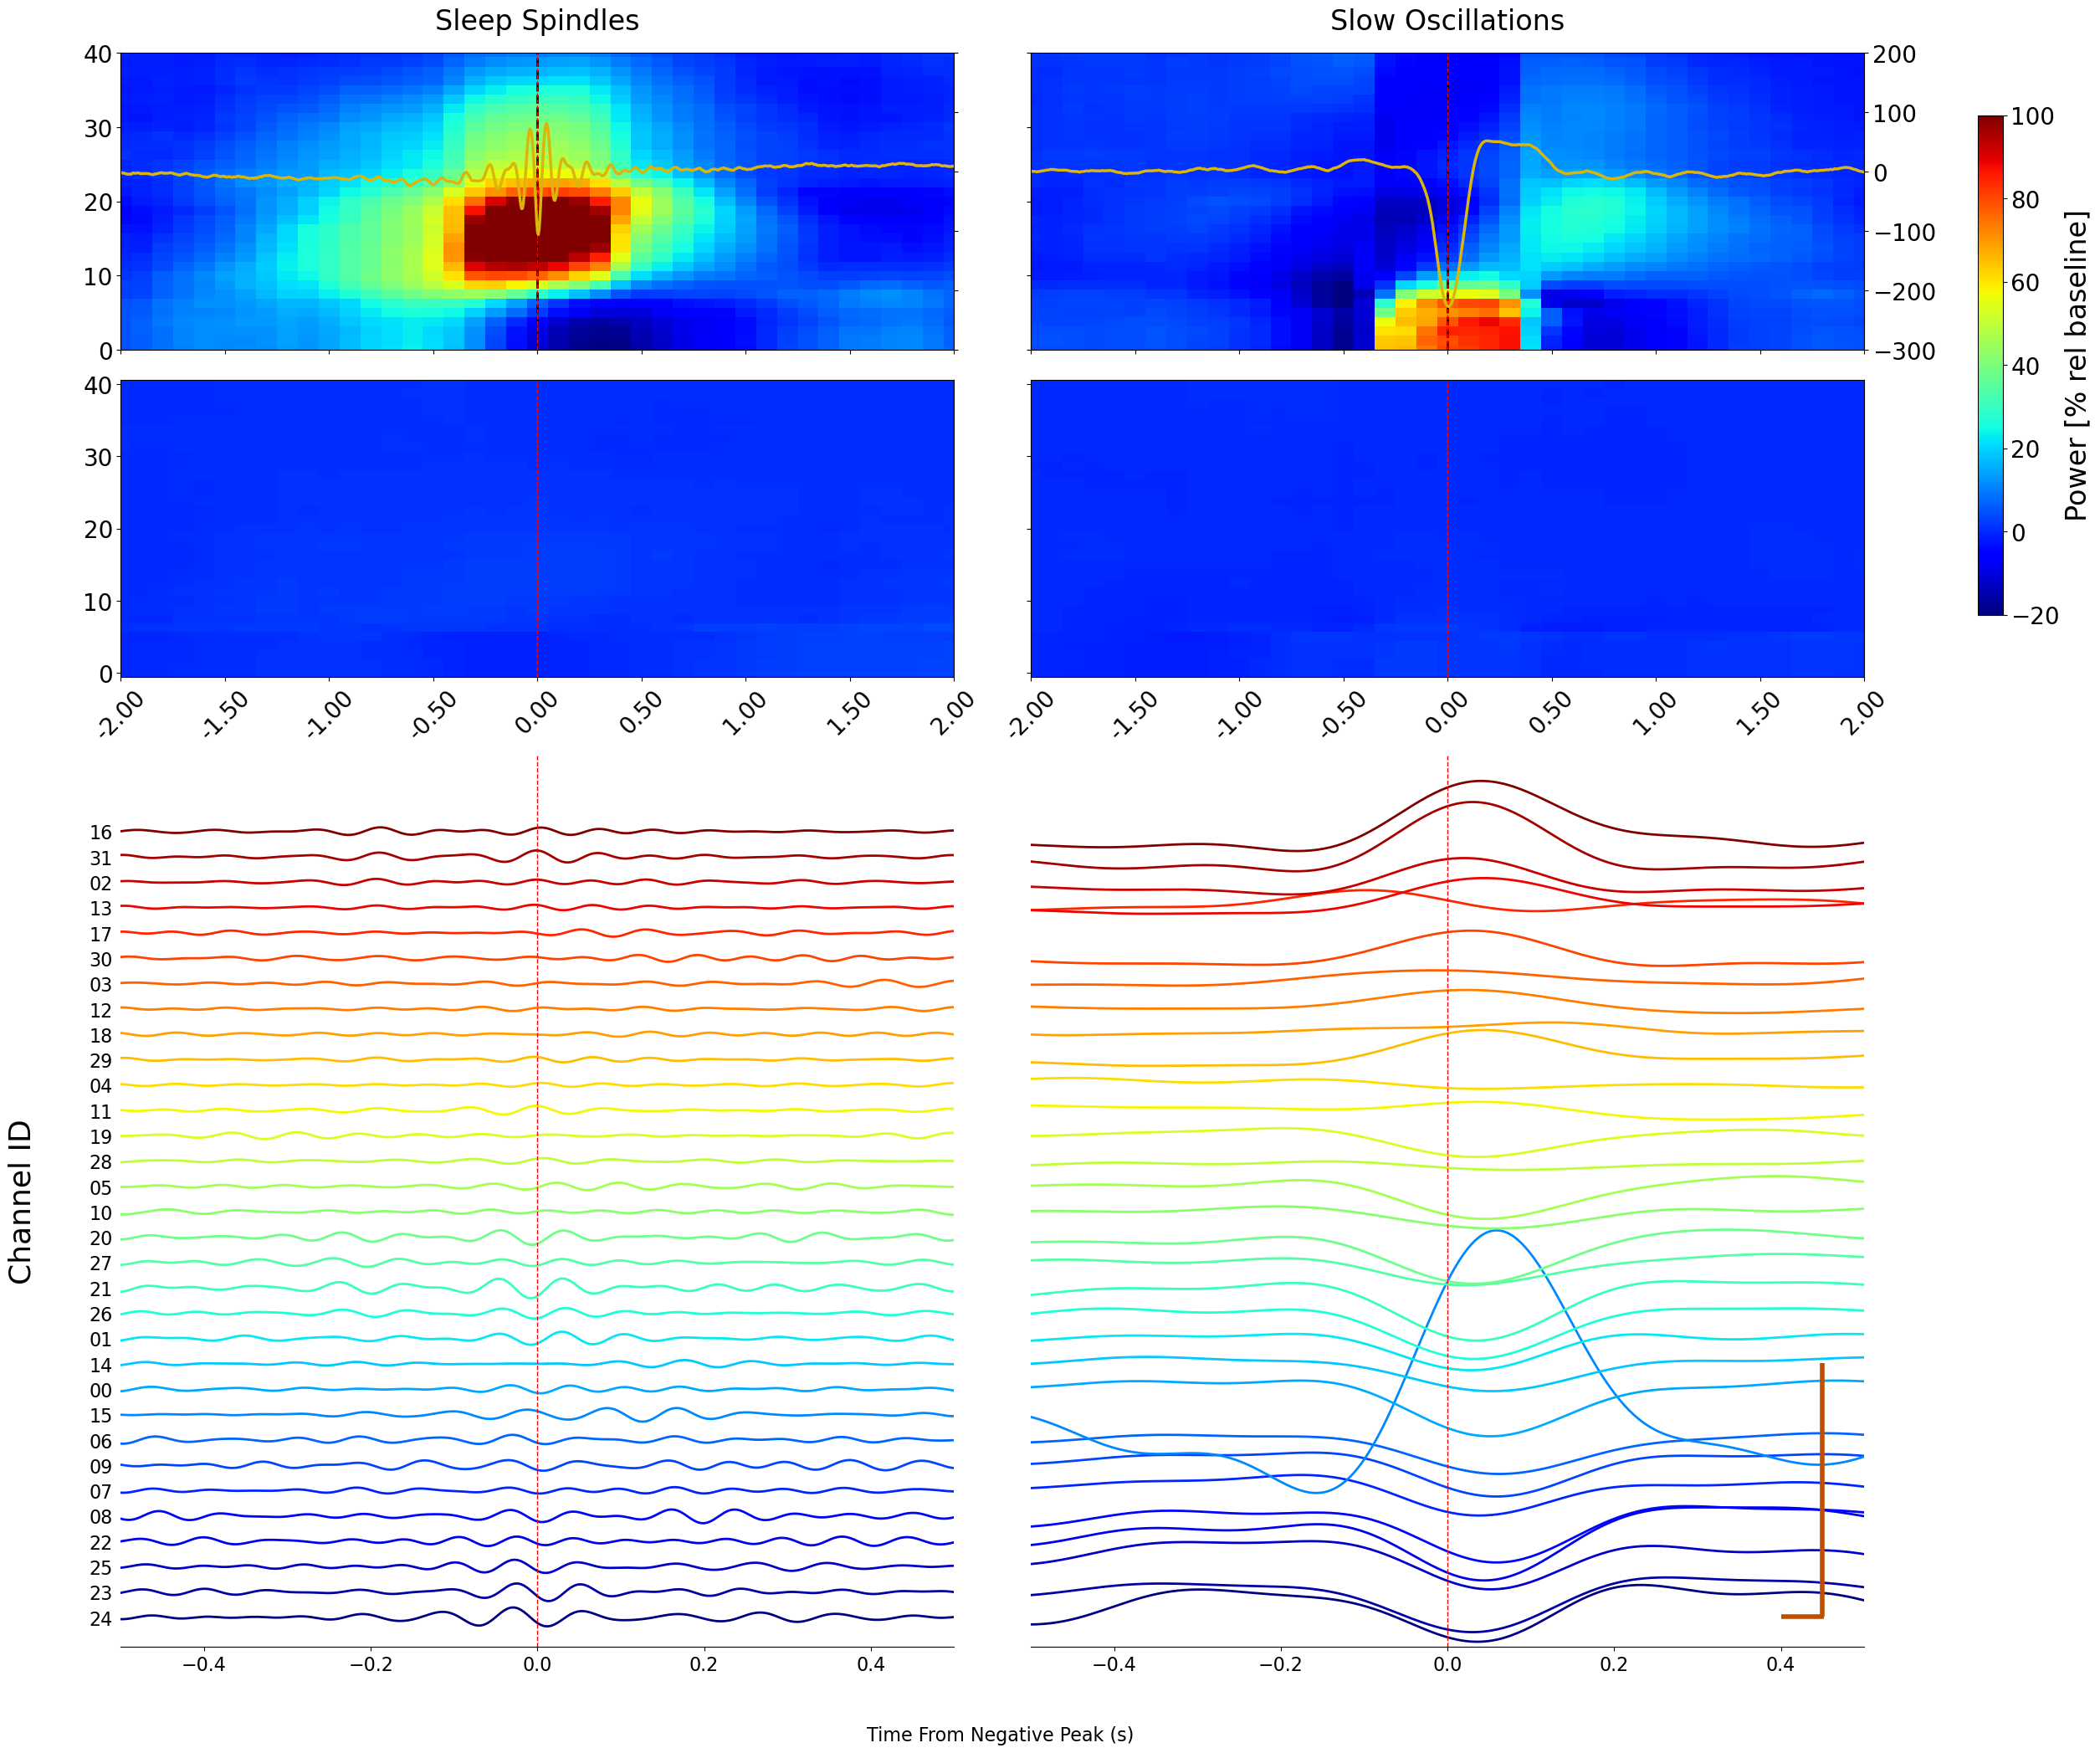

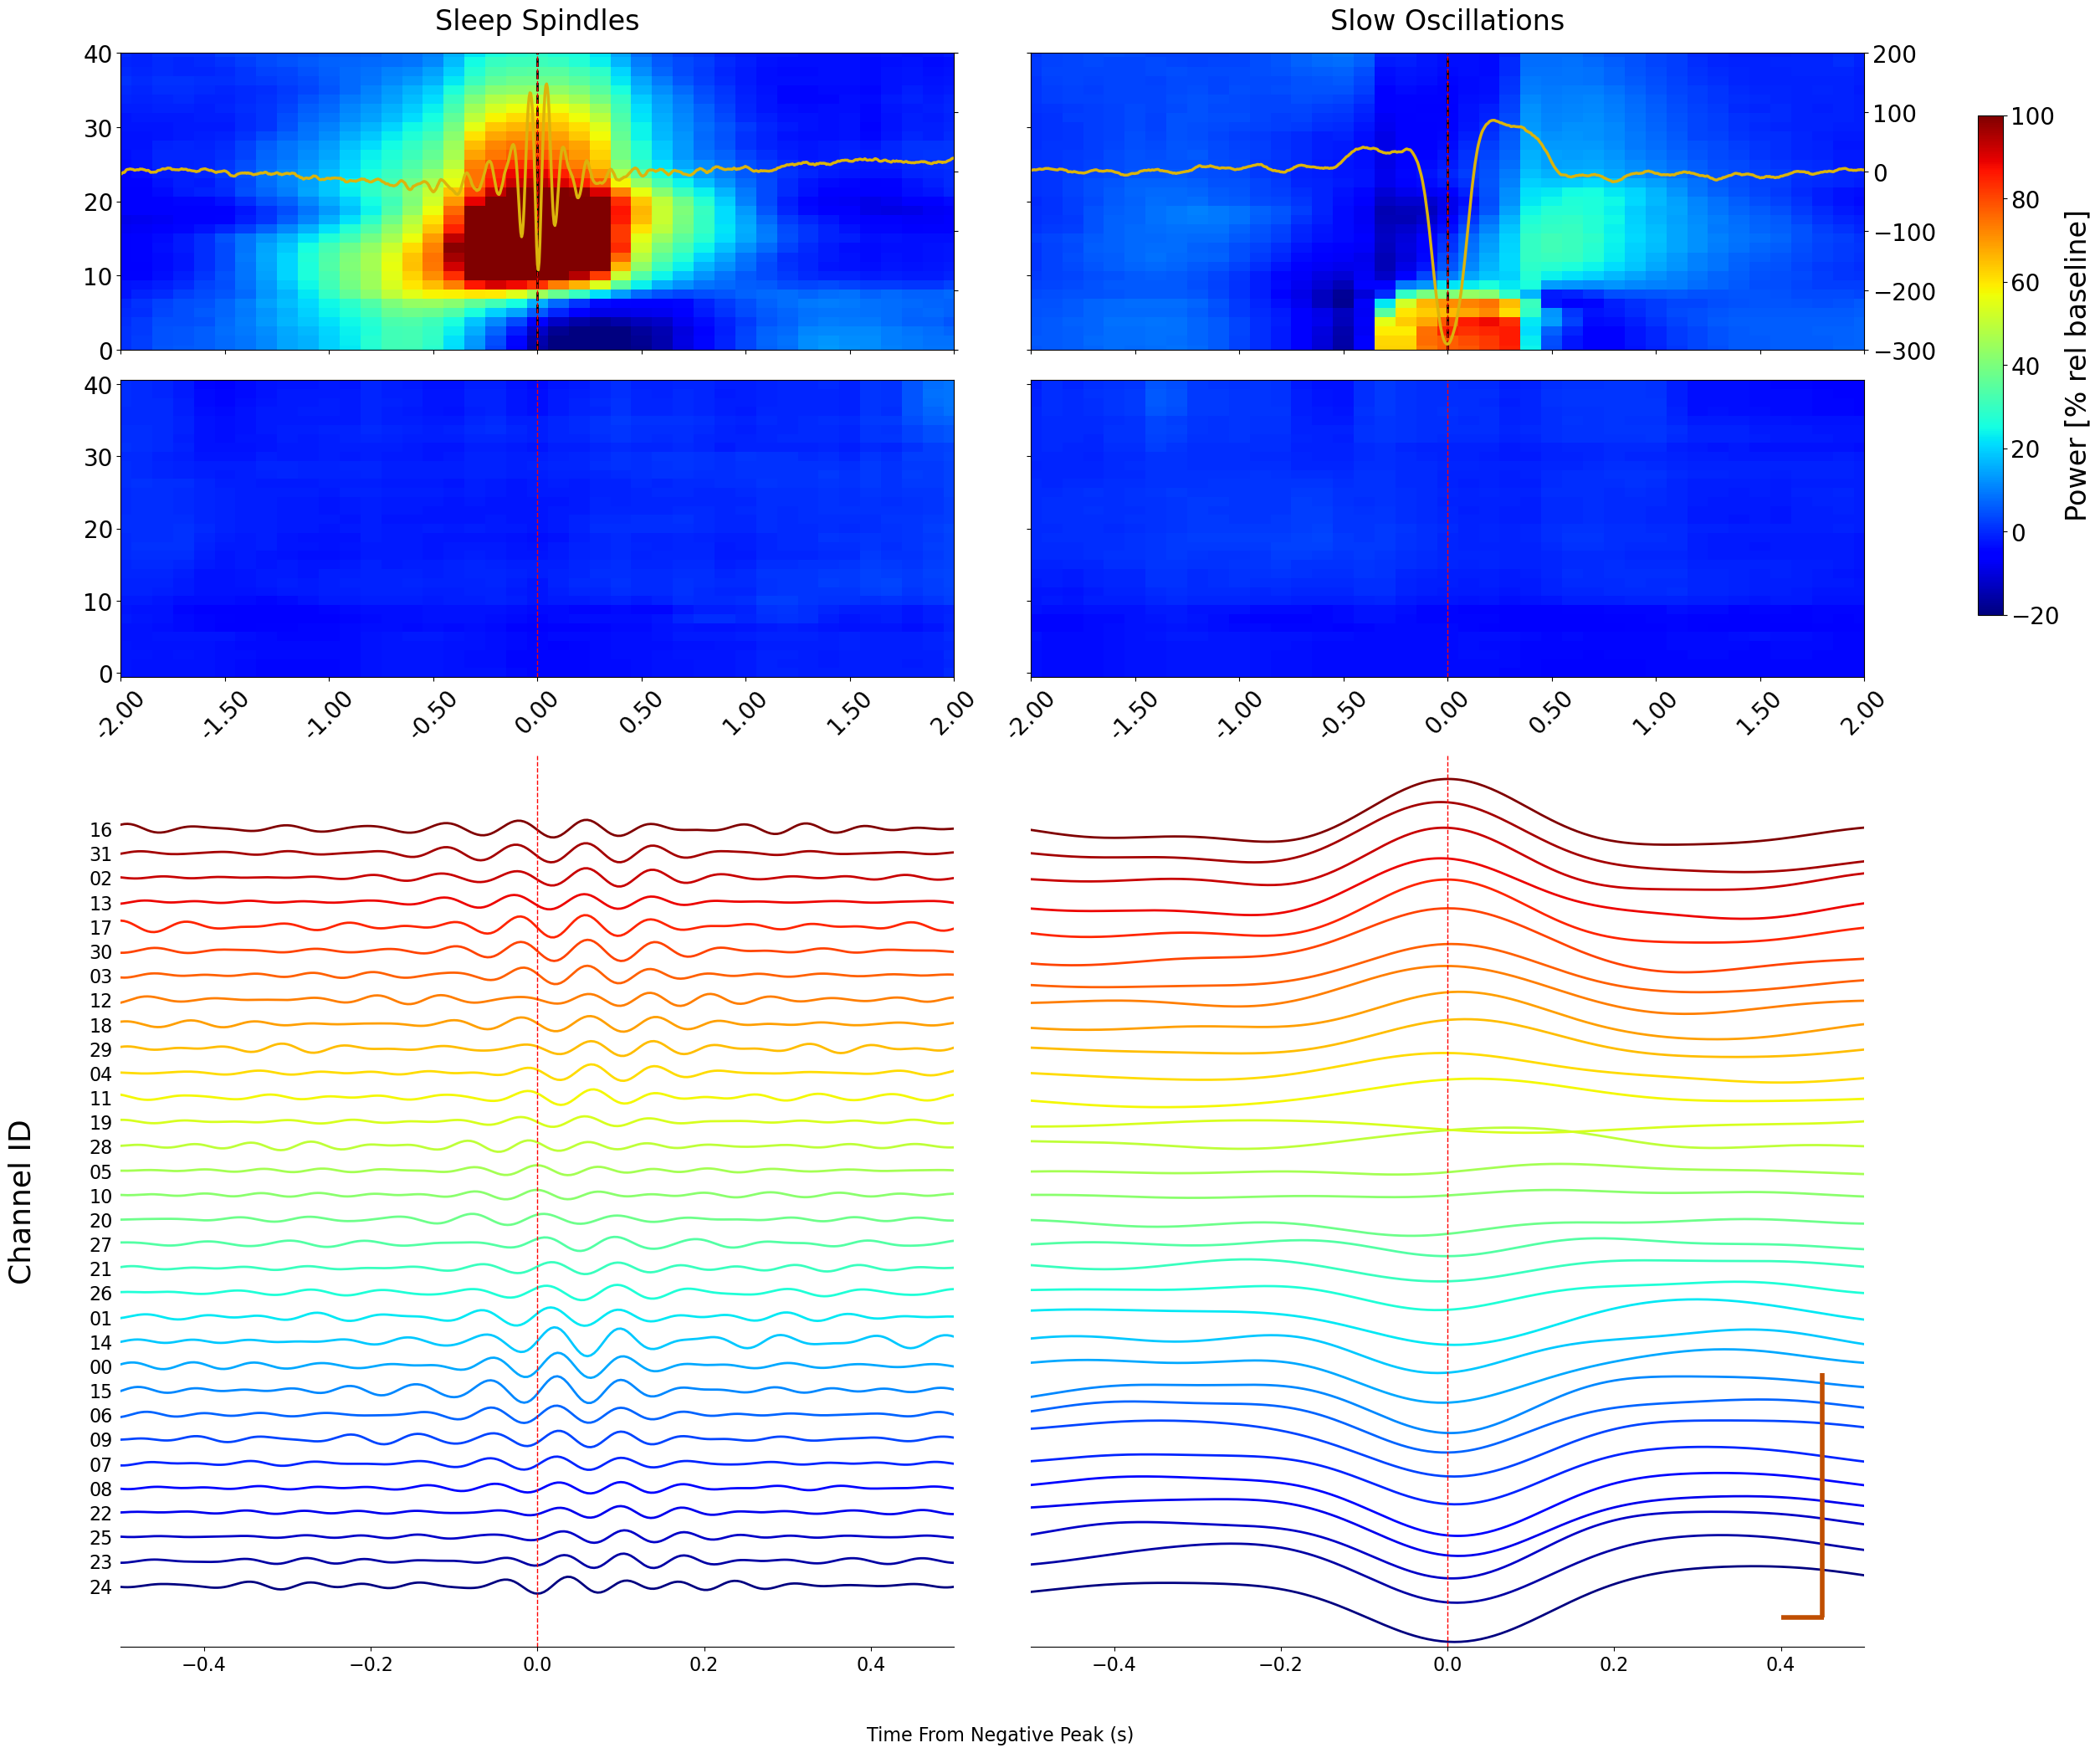

In [44]:
for animal in ["HYDO03", "HYDO04"]:
    spectra_window = 2
    plot_window = 0.5
    zero_ind = int(window * 250)
    win_ind = np.ceil(spectra_window * 250).astype(int)
    time_slice = slice(-2.1, 2.1)
    plot_slice = slice(-2.0, 2.0)
    freq_lims = slice(0, 40.1)
    scaler = 5
    vmin, vmax = -20, 100
    print("plotting")
    print(animal)
    depth_ordered_chs = si.depth_order(rec_dict[animal]["hyp"]["raw"]).get_channel_ids()
    colors = plt.cm.jet(np.linspace(0, 1, len(depth_ordered_chs)))
    depth_ordered_chs_ctx = np.append(
        depth_ordered_chs,
        list(spi_traces[animal]["ctx"].keys()),
    )
    tmp_time = (
        np.arange(np.round(spectra_window, 2) * 2 * 250 + 1)
        - (np.round(spectra_window, 2) * 250)
    ) / 250
    fig1, axs1 = plt.subplots(
        nrows=3,
        ncols=2,
        height_ratios=[3, 3, 9],
        figsize=(25, 20),
        constrained_layout=True,
        sharex="row",
        sharey="row",
    )
    region = "ctx"
    ax = axs1[0, :]
    ax0 = ax[0].twinx()
    ax1 = ax[1].twinx()
    ax1.sharey(ax0)
    channel = ["39"] if region == "ctx" else ["21", "16"]
    # tmp_data_spi = xr.concat(animal_xr_dict[animal]["spi-peak"]["ctx"], dim="epoch")
    # tmp_data_so = xr.concat(animal_xr_dict[animal]["so-peak"]["ctx"], dim="epoch")
    tmp_data_spi = animal_xr_dict[animal]["spi-peak"]["ctx"][1]
    tmp_data_so = animal_xr_dict[animal]["so-peak"]["ctx"][1]
    spectra_spi = xr_baseline_correction(tmp_data_spi, baseline_segment=slice(-4, -2))
    # spectra_spi = spectra_spi.mean(dim=("channel", "epoch"), skipna=True)
    spectra_spi = spectra_spi.mean(dim=("channel"), skipna=True)
    spectra_so = xr_baseline_correction(tmp_data_so, baseline_segment=slice(-4, -2))
    # spectra_so = spectra_so.mean(dim=("channel", "epoch"), skipna=True)
    spectra_so = spectra_so.mean(dim=("channel"), skipna=True)
    im = axs1[0, 0].pcolormesh(
        spectra_spi.sel(time=time_slice).time.values,
        spectra_spi.sel(freq=freq_lims).freq.values,
        spectra_spi.sel(freq=freq_lims, time=time_slice).T,
        cmap="jet",
        vmin=vmin,
        vmax=vmax,
    )
    im = axs1[0, 1].pcolormesh(
        spectra_so.sel(time=time_slice).time.values,
        spectra_so.sel(freq=freq_lims).freq.values,
        spectra_so.sel(freq=freq_lims, time=time_slice).T,
        cmap="jet",
        vmin=vmin,
        vmax=vmax,
    )
    # for filt_type, color in zip(
    #     [("raw", "raw"), ("so", "spi")], ["#029386", "#c04e01"]
    # ):
    for filt_type, color in zip([("raw", "raw")], ["#dbb40c"]):
        for ch in channel:
            label = "raw trace" if filt_type[0] == "raw" else "filtered trace"
            ax0.plot(
                tmp_time,
                spi_traces[animal][region][filt_type[1]][ch].mean(axis=0)[
                    zero_ind - win_ind : zero_ind + win_ind + 1
                ],
                label=label,
                lw=2.5,
                c=color,
            )
            ax1.plot(
                tmp_time,
                so_traces[animal][region][filt_type[0]][ch].mean(axis=0)[
                    zero_ind - win_ind : zero_ind + win_ind + 1
                ],
                label=label,
                lw=2.5,
                c=color,
            )
    ax[0].axvline(x=0, c="k", ls="--", lw=2)
    ax[1].axvline(x=0, c="k", ls="--", lw=2)
    ax[0].spines[["top", "right", "bottom"]].set_visible(False)
    ax[1].spines[["top", "right", "bottom"]].set_visible(False)
    ax[0].set_xlim([plot_slice.start, plot_slice.stop])
    ax[1].set_xlim([plot_slice.start, plot_slice.stop])
    ax[0].set_ylim([0, 40])
    ax[1].set_ylim([0, 40])
    ax0.set_ylim([-300, 200])
    ax1.set_ylim([-300, 200])
    ax[0].set_title("Sleep Spindles", fontsize=24, pad=20)
    ax[1].set_title("Slow Oscillations", fontsize=24, pad=20)
    ax0.yaxis.set_tick_params(labelright=False)
    # ax[0].set_ylabel("Amplitude ($\\mu$V)", fontsize=26, labelpad=10)  # x=-0.06)
    tmp_data_spi = xr.concat(animal_xr_dict[animal]["spi-peak"]["hyp"], dim="epoch")
    tmp_data_so = xr.concat(animal_xr_dict[animal]["so-peak"]["hyp"], dim="epoch")
    spectra_spi = xr_baseline_correction(tmp_data_spi, baseline_segment=slice(-4, -2))
    spectra_spi = spectra_spi.mean(dim=("channel", "epoch"), skipna=True)
    spectra_so = xr_baseline_correction(tmp_data_so, baseline_segment=slice(-4, -2))
    spectra_so = spectra_so.mean(dim=("channel", "epoch"), skipna=True)
    axs1[1, 0].sharex(axs1[0, 0])
    # axs1[1, 1].sharex(axs1[0, 0])
    im = axs1[1, 0].pcolormesh(
        spectra_spi.sel(time=time_slice).time.values,
        spectra_spi.sel(freq=freq_lims).freq.values,
        spectra_spi.sel(freq=freq_lims, time=time_slice).T,
        cmap="jet",
        vmin=vmin,
        vmax=vmax,
    )
    im = axs1[1, 1].pcolormesh(
        spectra_so.sel(time=time_slice).time.values,
        spectra_so.sel(freq=freq_lims).freq.values,
        spectra_so.sel(freq=freq_lims, time=time_slice).T,
        cmap="jet",
        vmin=vmin,
        vmax=vmax,
    )
    fig1.colorbar(
        im,
        ax=axs1[:2, 1].ravel().tolist(),
        label="Power [% rel baseline]",
        shrink=0.8,
    )
    for ax in axs1[1, :].ravel():
        _ = ax.set_xticks(
            ticks=np.arange(-spectra_window, spectra_window + 0.01, 0.5),
            labels=[
                f"{x:.2f}"
                for x in np.arange(-spectra_window, spectra_window + 0.01, 0.5)
            ],
            rotation=45,
        )
    for ax in axs1[0, :].ravel():
        _ = ax.xaxis.set_tick_params(labelbottom=False)

    y_tick_labels = []
    tmp_time = (
        np.arange(np.round(plot_window, 2) * 2 * 250 + 1)
        - (np.round(plot_window, 2) * 250)
    ) / 250
    win_ind = np.ceil(plot_window * 250).astype(int)
    axs1[2, 0].set_prop_cycle("color", colors)
    axs1[2, 1].set_prop_cycle("color", colors)
    for ind, ch in enumerate(depth_ordered_chs):
        if int(ch) <= 32:
            region = "hyp"
            ls = "-"
        else:
            region = "ctx"
            ls = "-"
        tmp_trace_spi = spi_traces[animal][region]["spi"][ch]
        tmp_trace_so = so_traces[animal][region]["so"][ch]
        axs1[2, 0].plot(
            tmp_time,
            (tmp_trace_spi.T.mean(axis=1)[zero_ind - win_ind : zero_ind + win_ind + 1])
            + (scaler * ind),
            # c=color,
            lw=2,
            ls=ls,
        )
        axs1[2, 1].plot(
            tmp_time,
            (tmp_trace_so.T.mean(axis=1)[zero_ind - win_ind : zero_ind + win_ind + 1])
            + (scaler * ind),
            # c=color,
            lw=2,
            ls=ls,
        )

        y_tick_labels.append(
            f"{int(ch):02d}"  # ({rec_dict[animal][region].id_to_index(ch) +1:02d})"
        )
    min_spi_y = (
        spi_traces[animal]["hyp"]["spi"][depth_ordered_chs[0]]
        .T.mean(axis=1)[zero_ind - win_ind : zero_ind + win_ind + 1]
        .min()
    )
    min_so_y = (
        so_traces[animal]["hyp"]["so"][depth_ordered_chs[0]]
        .T.mean(axis=1)[zero_ind - win_ind : zero_ind + win_ind + 1]
        .min()
    )
    min_y = min(min_spi_y, min_so_y)
    for a1 in axs1.flatten():
        a1.axvline(x=0, color="r", lw=1, ls="--")
    axs1[2, 1].vlines(x=0.45, ymin=min_y + 5, ymax=min_y + 55, colors="#c04e01", lw=4)
    axs1[2, 1].hlines(y=min_y + 5, xmin=0.4, xmax=0.452, colors="#c04e01", lw=4)

    _ = axs1[2, 0].set_yticks(
        ticks=np.arange(0, len(y_tick_labels) * scaler, scaler),
        labels=y_tick_labels,
    )

    axs1[2, 0].set_ylabel(
        "Channel ID",
        fontsize=26,
        labelpad=45,
    )
    fig1.supxlabel("Time From Negative Peak (s)                 ", fontsize=16, y=-0.04)

    axs1[2, 0].yaxis.set_tick_params(
        bottom=False, labelbottom=True, which="major", labelsize=16
    )
    axs1[2, 0].xaxis.set_tick_params(
        bottom=True, labelbottom=True, which="major", labelsize=16
    )

    axs1[2, 1].yaxis.set_tick_params(
        bottom=False, labelbottom=False, which="major", labelsize=16
    )
    axs1[2, 1].xaxis.set_tick_params(
        bottom=True, labelbottom=True, which="major", labelsize=16
    )

    axs1[2, 0].set_xlim([-0.5, 0.5])
    axs1[2, 0].set_ylim([min_y - 1, (len(depth_ordered_chs) * scaler) + scaler])
    axs1[2, 1].set_xlim([-0.5, 0.5])
    axs1[2, 1].set_ylim([min_y - 1, (len(depth_ordered_chs) * scaler) + 10])

    axs1[2, 0].spines[
        [
            "right",
            "left",
            "top",
        ]
    ].set_visible(False)
    axs1[2, 1].spines[
        [
            "right",
            "left",
            "top",
        ]
    ].set_visible(False)
    # fig1.tight_layout()
    # fig1.savefig(
    #     Path(
    #         "/gpfs01/born/animal/DanielG/hypo_sleep/figures/",
    #         f"{animal}_ch_traces_fig.png",
    #     ),
    #     dpi=500,
    #     facecolor="white",
    #     transparent=False,
    #     bbox_inches="tight",
    # )

In [ ]:
for ch in depth_ordered_chs